Проект Морозова Софья, 211, по курсу "Статистический анализ в Python"

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import math
from scipy import stats
import pylab
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from statsmodels.formula.api import ols
from sklearn.datasets import make_regression
from sklearn.preprocessing import scale, PolynomialFeatures, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn import datasets
from __future__ import print_function
import patsy
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix,roc_auc_score, roc_curve,classification_report,ConfusionMatrixDisplay
from patsy import dmatrices
from io import StringIO
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

Описание датасета

Датасет представляет собой набор финансовых критериев, касающихся кредитов. На основе этих признаков будем пытаться предсказать кредитный рейтинг пользователей — Credit_Score. Кредитный рейтинг может быть одним из трех типов: хороший, стандартный, плохой.
1. Occupation — Род занятий
2. Annual_Income — Годовой доход
3. Monthly_Inhand_Salary — Ежемесячная зарплата
4. Num_Bank_Accounts — Количество банковских счетов
5. Num_Credit_Card — Количество кредитных карт
6. Interest_Rate — Процентная ставка
7. Num_of_Loan — Количество кредитов
8. Delay_from_due_date — Отложенный срок выполнения
9. Num_of_Delayed_Payment — Количество просроченных платежей
10. Changed_Credit_Limit — Изменен кредитный лимит
11. Num_Credit_Inquiries — Количество запросов по кредитам
12. Credit_Mix — Структура кредитов
13. Outstanding_Debt — Непогашенная задолженность
14. Credit_Utilization_Ratio — Коэффициент использования кредита
15. Credit_History_Age — Возраст кредитной истории
16. Payment_of_Min_Amount — Минимальная сумма платежа
17. Total_EMI_per_month — Общий объем инвестиций в месяц
18. Amount_invested_monthly — Сумма ежемесячных инвестиций
19. Payment_Behaviour — Порядок осуществления платежей
20. Monthly_Balance — Баланс за месяц

In [2]:
df = pd.read_csv('Credit_score_cleaned_data.csv')
df

,Customer_ID,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Last_Loan_9,Last_Loan_8,Last_Loan_7,Last_Loan_6,Last_Loan_5,Last_Loan_4,Last_Loan_3,Last_Loan_2,Last_Loan_1,Credit_Score
0,CUS_0x98ed,31,Journalist,22229.060,1672.421667,6,4,5.0,3,10,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Debt Consolidation Loan,Standard
1,CUS_0x36b4,43,Musician,17060.705,1685.725417,8,3,11.0,4,24,...,No Loan,No Loan,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Auto Loan,Auto Loan,Standard
2,CUS_0x105b,24,Accountant,34428.210,2575.017500,2,4,8.0,0,3,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Good
3,CUS_0x4c4a,21,Accountant,12613.920,1155.160000,4,6,13.0,3,14,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Personal Loan,Student Loan,Home Equity Loan,Standard
4,CUS_0x612f,31,Journalist,34775.160,3048.930000,7,9,25.0,5,20,...,No Loan,No Loan,No Loan,No Loan,Auto Loan,Mortgage Loan,Auto Loan,Payday Loan,Not Specified,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0xc52a,46,Writer,35032.660,2853.388333,10,6,33.0,7,48,...,No Loan,No Loan,Credit-Builder Loan,Student Loan,Personal Loan,Mortgage Loan,Payday Loan,Payday Loan,Student Loan,Poor
99996,CUS_0x83cc,34,Engineer,125047.240,10682.603333,2,5,9.0,0,11,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Standard
99997,CUS_0x6ae6,26,Lawyer,9045.485,644.664842,8,7,20.0,6,52,...,No Loan,No Loan,No Loan,Not Specified,Student Loan,Auto Loan,Not Specified,Student Loan,Auto Loan,Poor
99998,CUS_0x6f0c,20,Lawyer,53564.880,4207.740000,5,3,13.0,2,6,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Mortgage Loan,Personal Loan,Standard


In [4]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,33.309240,50505.123449,4198.771859,5.368800,5.533640,14.53208,3.532880,21.068780,13.329240,10.389098,5.772820,1426.220376,32.285173,221.206880,88.209450,193.686347,403.492393
std,10.764996,38299.422093,3187.494345,2.593279,2.067073,8.74133,2.446356,14.860104,6.269066,6.783550,3.861137,1155.129026,5.116875,99.681112,83.244703,194.785222,214.423009
min,14.000000,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,-5.000000,0.000000,-6.490000,0.000000,0.230000,20.000000,1.000000,-1.000000,0.000000,0.007760
25%,24.000000,19342.972500,1626.761667,3.000000,4.000000,7.00000,2.000000,10.000000,9.000000,5.340000,3.000000,566.072500,28.052567,144.000000,25.589532,73.730625,270.322511
50%,33.000000,36999.705000,3096.378333,5.000000,5.000000,13.00000,3.000000,18.000000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,61.541296,129.361839,337.270985
75%,42.000000,71683.470000,5961.745000,7.000000,7.000000,20.00000,5.000000,28.000000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,131.528154,234.346249,471.928804
max,56.000000,179987.280000,15204.633333,11.000000,11.000000,34.00000,9.000000,67.000000,28.000000,36.970000,17.000000,4998.070000,50.000000,404.000000,357.406068,1977.326102,1602.040519


In [5]:
df.isnull().all()

Customer_ID                 False
Age                         False
Occupation                  False
Annual_Income               False
Monthly_Inhand_Salary       False
Num_Bank_Accounts           False
Num_Credit_Card             False
Interest_Rate               False
Num_of_Loan                 False
Delay_from_due_date         False
Num_of_Delayed_Payment      False
Changed_Credit_Limit        False
Num_Credit_Inquiries        False
Credit_Mix                  False
Outstanding_Debt            False
Credit_Utilization_Ratio    False
Credit_History_Age          False
Payment_of_Min_Amount       False
Total_EMI_per_month         False
Amount_invested_monthly     False
Payment_Behaviour           False
Monthly_Balance             False
Last_Loan_9                 False
Last_Loan_8                 False
Last_Loan_7                 False
Last_Loan_6                 False
Last_Loan_5                 False
Last_Loan_4                 False
Last_Loan_3                 False
Last_Loan_2   

Для начала попытаемся эмпирически определить вид распределения для каждой переменной. Будем накладывать на распределения линии распределений: Нормального, Логнормального, Экспоненциального, Гаммы, Вейбуллы, Обратной Гаммы.

In [207]:
def estimate_weibull_params(data, lo=0.1, hi=10.0, iters=50):
    m = data.mean()
    v = data.var(ddof=0)
    target = v / m**2
    def f(k):
        return math.gamma(1 + 2/k) / (math.gamma(1 + 1/k)**2) - 1 - target
    a, b = lo, hi
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        return None
    for _ in range(iters):
        mid = 0.5 * (a + b)
        if fa * f(mid) <= 0:
            b = mid
            fb = f(mid)
        else:
            a = mid
            fa = f(a)
    k = 0.5 * (a + b)
    lam = m / math.gamma(1 + 1/k)
    return k, lam

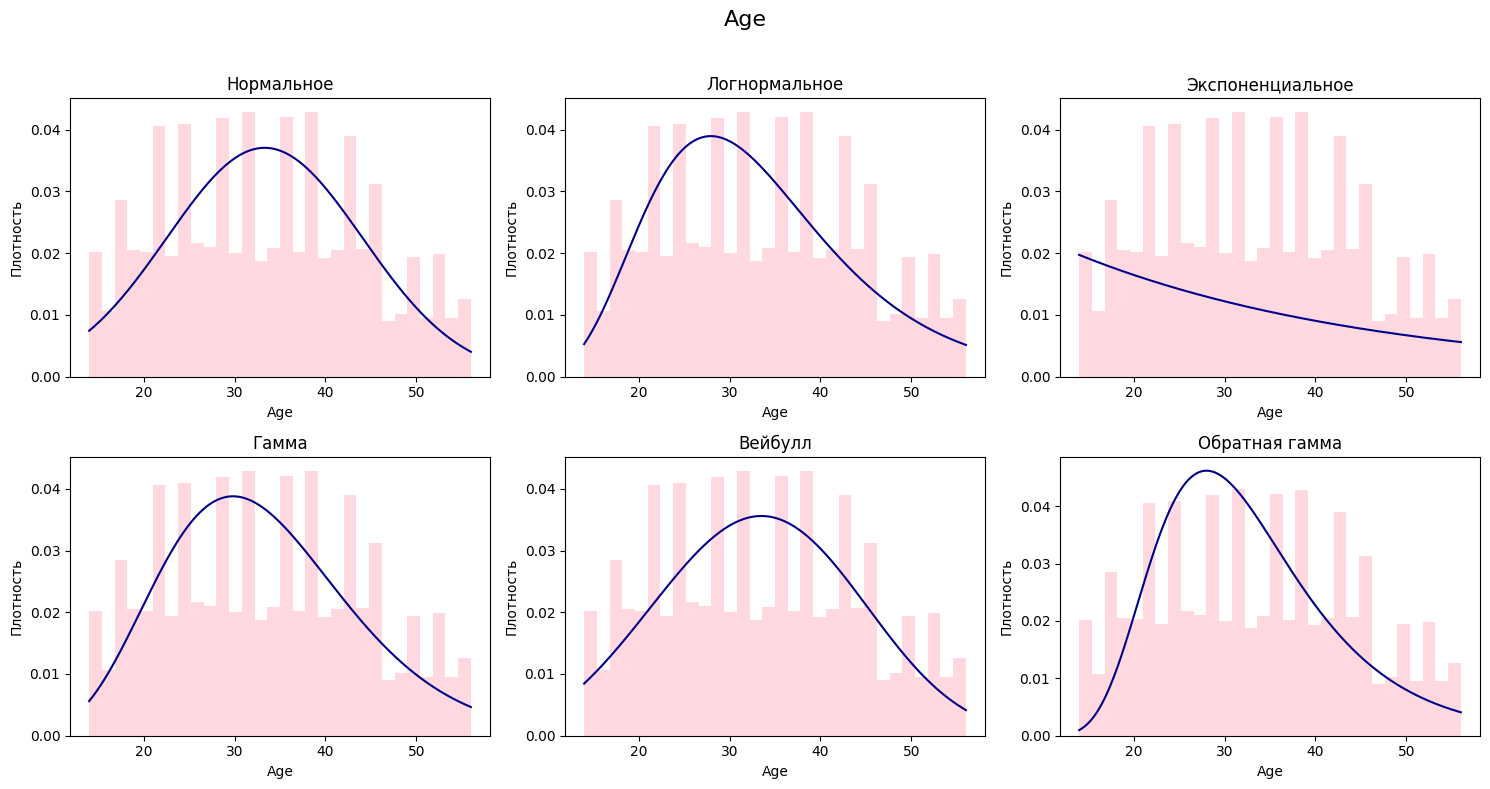

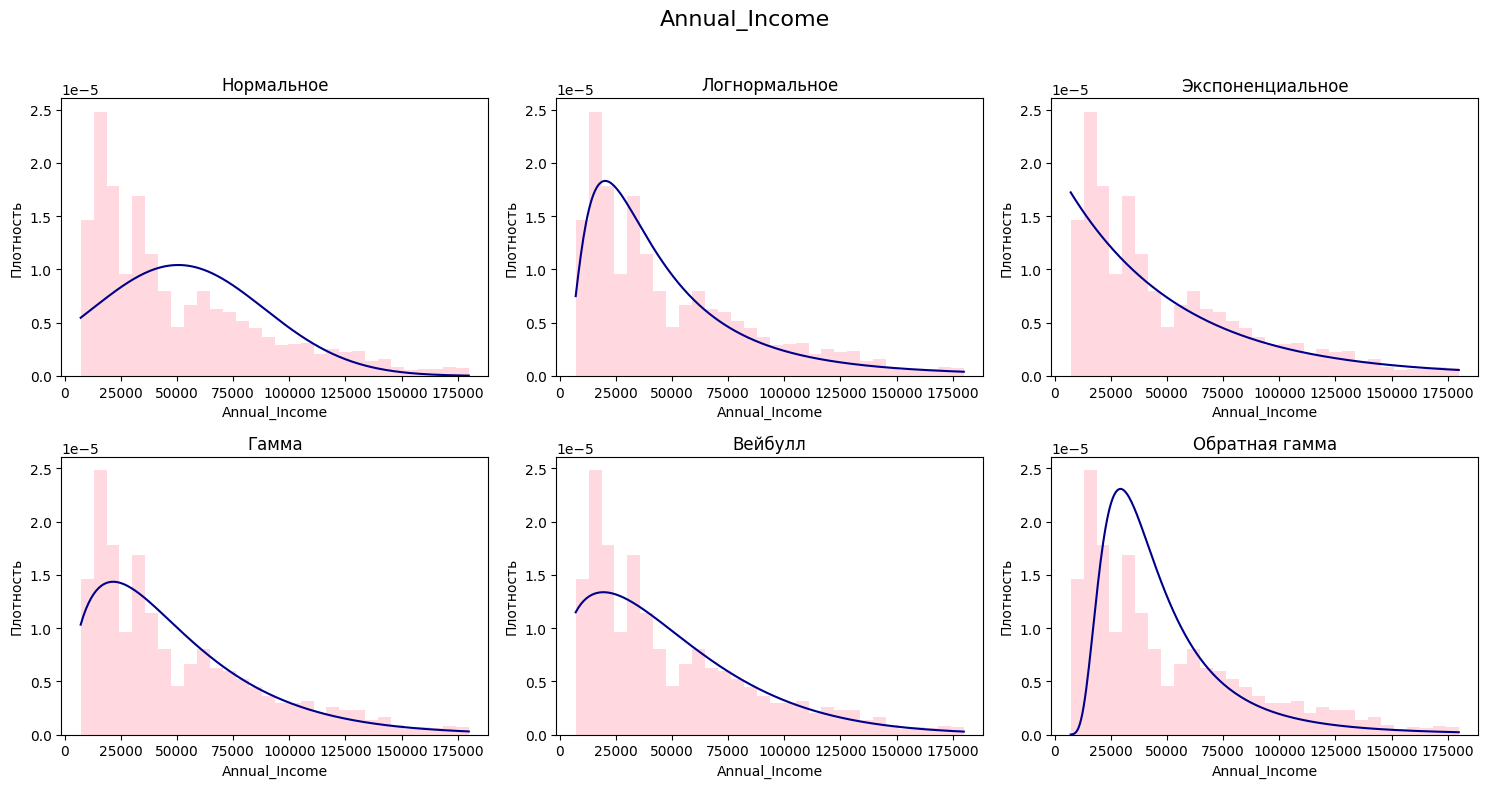

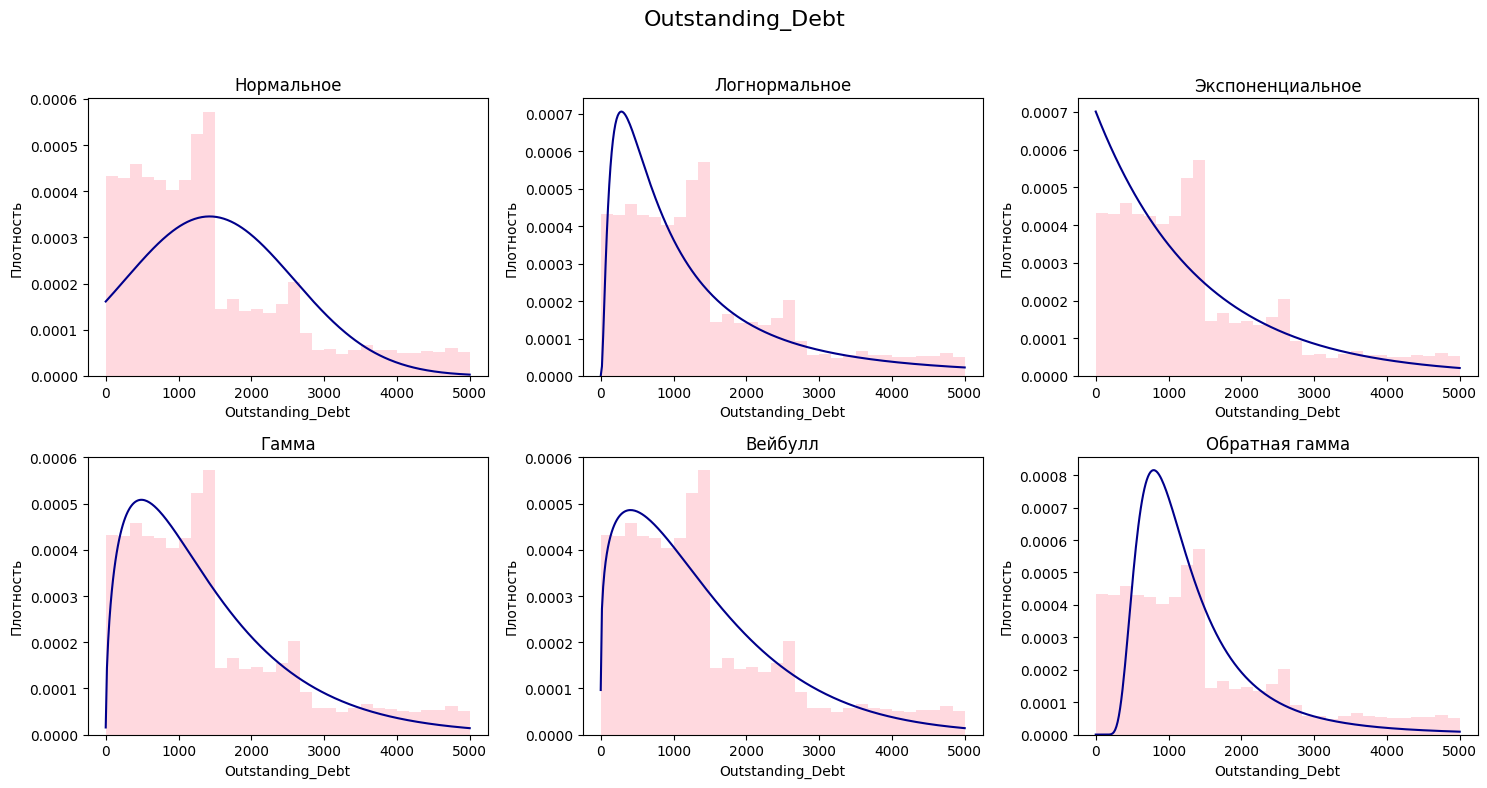

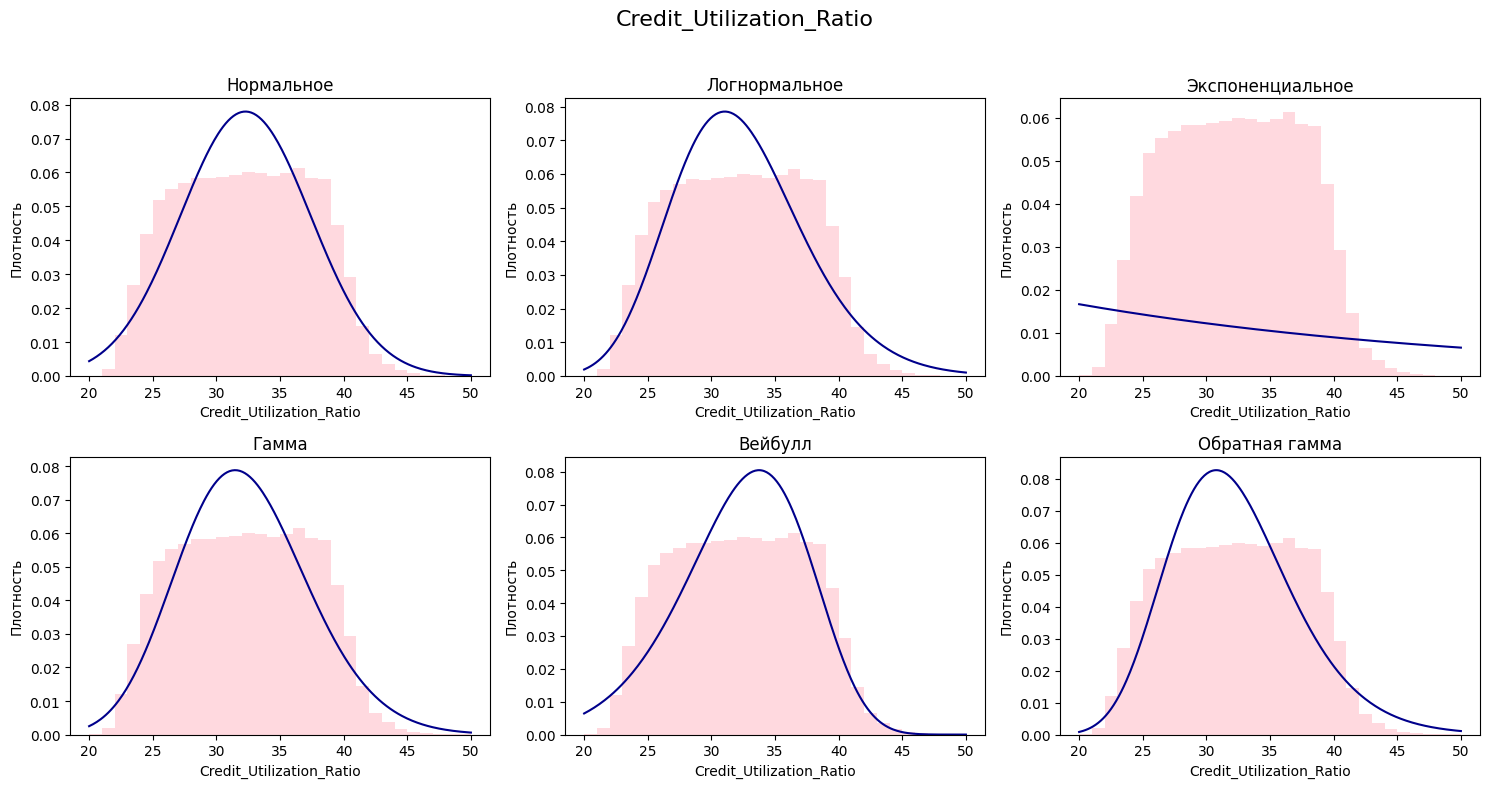

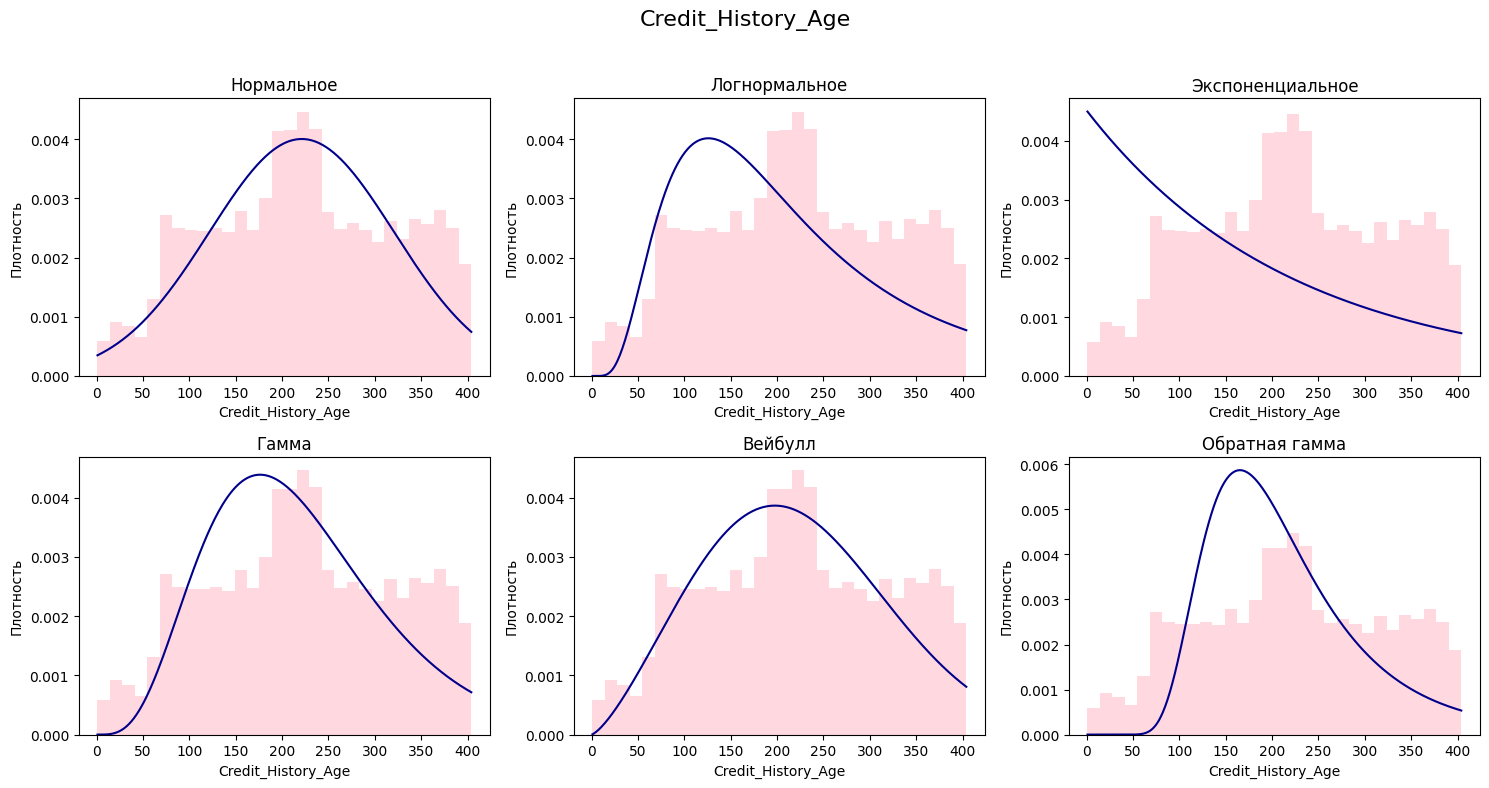

In [208]:
numeric_vars = [
    'Age',
    'Annual_Income',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Credit_History_Age'
]

for var in numeric_vars:
    data = df[var].dropna().values
    x_min, x_max = data.min(), data.max()
    x = np.linspace(x_min, x_max, 300)
    
    #норм
    mu, sigma = data.mean(), data.std(ddof=0)
    pdf_norm = 1/(sigma * math.sqrt(2*math.pi)) * np.exp(-0.5 * ((x - mu)/sigma)**2)
    
    #логнорм
    pos = data[data > 0]
    mu_ln, sigma_ln = np.log(pos).mean(), np.log(pos).std(ddof=0)
    pdf_logn = (1/(x * sigma_ln * math.sqrt(2*math.pi))
                * np.exp(-0.5 * ((np.log(x) - mu_ln)/sigma_ln)**2))
    
    #экспон
    lam = 1 / data.mean()
    pdf_exp = lam * np.exp(-lam * x)
    
    #гамма
    m, v = data.mean(), data.var(ddof=0)
    k_gamma = m**2 / v
    theta = v / m
    pdf_gamma = (x**(k_gamma - 1) * np.exp(-x/theta)
                 / (math.gamma(k_gamma) * theta**k_gamma))
    
    #вейбулл
    weib_params = estimate_weibull_params(data)
    if weib_params:
        k_w, lam_w = weib_params
        pdf_weib = (k_w/lam_w) * (x/lam_w)**(k_w - 1) * np.exp(-(x/lam_w)**k_w)
    else:
        pdf_weib = np.zeros_like(x)
    
    #обр гамма
    m, v = data.mean(), data.var(ddof=0)
    alpha = 2 + m**2 / v
    beta = m * (alpha - 1)
    pdf_inv_gamma = (beta**alpha / math.gamma(alpha)) * x**(-alpha-1) * np.exp(-beta / x)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    dist_pdfs = [
        ('Нормальное', pdf_norm),
        ('Логнормальное', pdf_logn),
        ('Экспоненциальное', pdf_exp),
        ('Гамма', pdf_gamma),
        ('Вейбулл', pdf_weib),
        ('Обратная гамма', pdf_inv_gamma)
    ]
    axes = axes.flatten()
    
    for ax, (name, pdf) in zip(axes, dist_pdfs):
        ax.hist(data, bins=30, density=True, alpha=0.6, color='pink')
        ax.plot(x, pdf, color='darkblue')
        ax.set_title(name)
        ax.set_xlabel(var)
        ax.set_ylabel('Плотность')
    
    plt.suptitle(f'{var}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Видно, что для Annual_Income Логнормальное распределение совпадает с хвостом -> предварительно берем его, для Outstanding_Debt и Credit_Utilization_Ratio лучше подходит Гамма, для Credit_History_Age - Вейбулл.

Формулируем гипотезы о распределении.
1. Переменная Annual_Income имеет Логнормальное распределение.
2. Переменная Outstanding_Debt имеет Гамма распределение.
3. Переменная Credit_Utilization_Ratio имеет Гамма распределение.
4. Переменная Credit_History_Age имеет распределение Вейбуллы.

In [3]:
vars2dist = {
    'Annual_Income'           : 'lognorm',
    'Outstanding_Debt'        : 'gamma',
    'Credit_Utilization_Ratio': 'gamma',
    'Credit_History_Age'      : 'weibull'
}

def fit_params(series: pd.Series, dist_name: str) -> dict:
    data = series.dropna().values
    if dist_name == 'lognorm':
        shape, loc, scale = stats.lognorm.fit(data, floc=0)
        return dict(shape=shape, loc=loc, scale=scale)

    if dist_name == 'gamma':
        alpha, loc, beta = stats.gamma.fit(data, floc=0)
        return dict(alpha=alpha, loc=loc, beta=beta)

    if dist_name == 'weibull':
        c, loc, scale = stats.weibull_min.fit(data, floc=0)
        return dict(c=c, loc=loc, scale=scale)


def ks_test(series: pd.Series, dist_name: str, params: dict):
    data = series.dropna().values
    if dist_name == 'lognorm':
        return stats.kstest(data, 'lognorm',
                            args=(params['shape'], params['loc'], params['scale']))
    if dist_name == 'gamma':
        return stats.kstest(data, 'gamma',
                            args=(params['alpha'], params['loc'], params['beta']))
    if dist_name == 'weibull':
        return stats.kstest(data, 'weibull_min',
                            args=(params['c'], params['loc'], params['scale']))


for col, dist in vars2dist.items():
    params = fit_params(df[col], dist)
    ks_stat, p_val = ks_test(df[col], dist, params)

    print(f"\n=== {col}  ~  {dist} ===")
    print("MLE-параметры:", {k: round(v, 4) for k, v in params.items()})
    print(f"Kolmogorov–и: statistic = {ks_stat:.4f},  p-value = {p_val:.4g}")

    if p_val < 0.05:
        print("не подходит")
    else:
        print("подходит")


=== Annual_Income  ~  lognorm ===
MLE-параметры: {'shape': np.float64(0.7906), 'loc': 0, 'scale': np.float64(37665.6459)}
Kolmogorov–и: statistic = 0.0691,  p-value = 0
не подходит

=== Outstanding_Debt  ~  gamma ===
MLE-параметры: {'alpha': 1.339, 'loc': 0, 'beta': np.float64(1065.1692)}
Kolmogorov–и: statistic = 0.0466,  p-value = 3.958e-189
не подходит

=== Credit_Utilization_Ratio  ~  gamma ===
MLE-параметры: {'alpha': 39.0643, 'loc': 0, 'beta': np.float64(0.8265)}
Kolmogorov–и: statistic = 0.0538,  p-value = 2.278e-252
не подходит

=== Credit_History_Age  ~  weibull ===
MLE-параметры: {'c': np.float64(2.3404), 'loc': 0, 'scale': np.float64(248.6475)}
Kolmogorov–и: statistic = 0.0460,  p-value = 1.166e-184
не подходит


По Колмагорову-Смирнову ни одна из нулевых гипотез не принимается. Подходящие, на первый взгляд, распределения для некоторых переменных, на самом деле не являются теми, какими они были предположены изначально.

Далее смотрим переменные, для которых p_value >= 0.5 и строим для подтверждения корреляционную матрицу.

In [4]:
df = pd.read_csv('Credit_score_cleaned_data.csv')

num_df = df.select_dtypes(include='number')

corr_mat = num_df.corr(method='pearson')

mask_upper = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
corr_pairs = corr_mat.where(mask_upper).stack().reset_index()
corr_pairs.columns = ['Var1', 'Var2', 'rho']

THRESH = 0.5
top_corr = corr_pairs.loc[abs(corr_pairs['rho']) >= THRESH] \
                      .sort_values(by='rho', key=abs, ascending=False)

print(f"\n=== ТОП-КОРРЕЛЯЦИИ (p_value >= {THRESH}) ===")
for _, row in top_corr.iterrows():
    print(f"{row.Var1:25s}  –  {row.Var2:25s}    ρ = {row.rho:+.3f}")



=== ТОП-КОРРЕЛЯЦИИ (p_value >= 0.5) ===
Annual_Income              –  Monthly_Inhand_Salary        ρ = +0.998
Monthly_Inhand_Salary      –  Monthly_Balance              ρ = +0.707
Annual_Income              –  Monthly_Balance              ρ = +0.706
Num_of_Loan                –  Outstanding_Debt             ρ = +0.639
Interest_Rate              –  Num_Credit_Inquiries         ρ = +0.634
Interest_Rate              –  Outstanding_Debt             ρ = +0.629
Outstanding_Debt           –  Credit_History_Age           ρ = -0.629
Monthly_Inhand_Salary      –  Amount_invested_monthly      ρ = +0.628
Annual_Income              –  Amount_invested_monthly      ρ = +0.627
Num_Credit_Inquiries       –  Credit_History_Age           ρ = -0.611
Num_of_Loan                –  Credit_History_Age           ρ = -0.606
Num_Bank_Accounts          –  Num_of_Delayed_Payment       ρ = +0.601
Num_Credit_Inquiries       –  Outstanding_Debt             ρ = +0.598
Interest_Rate              –  Delay_from_due_date

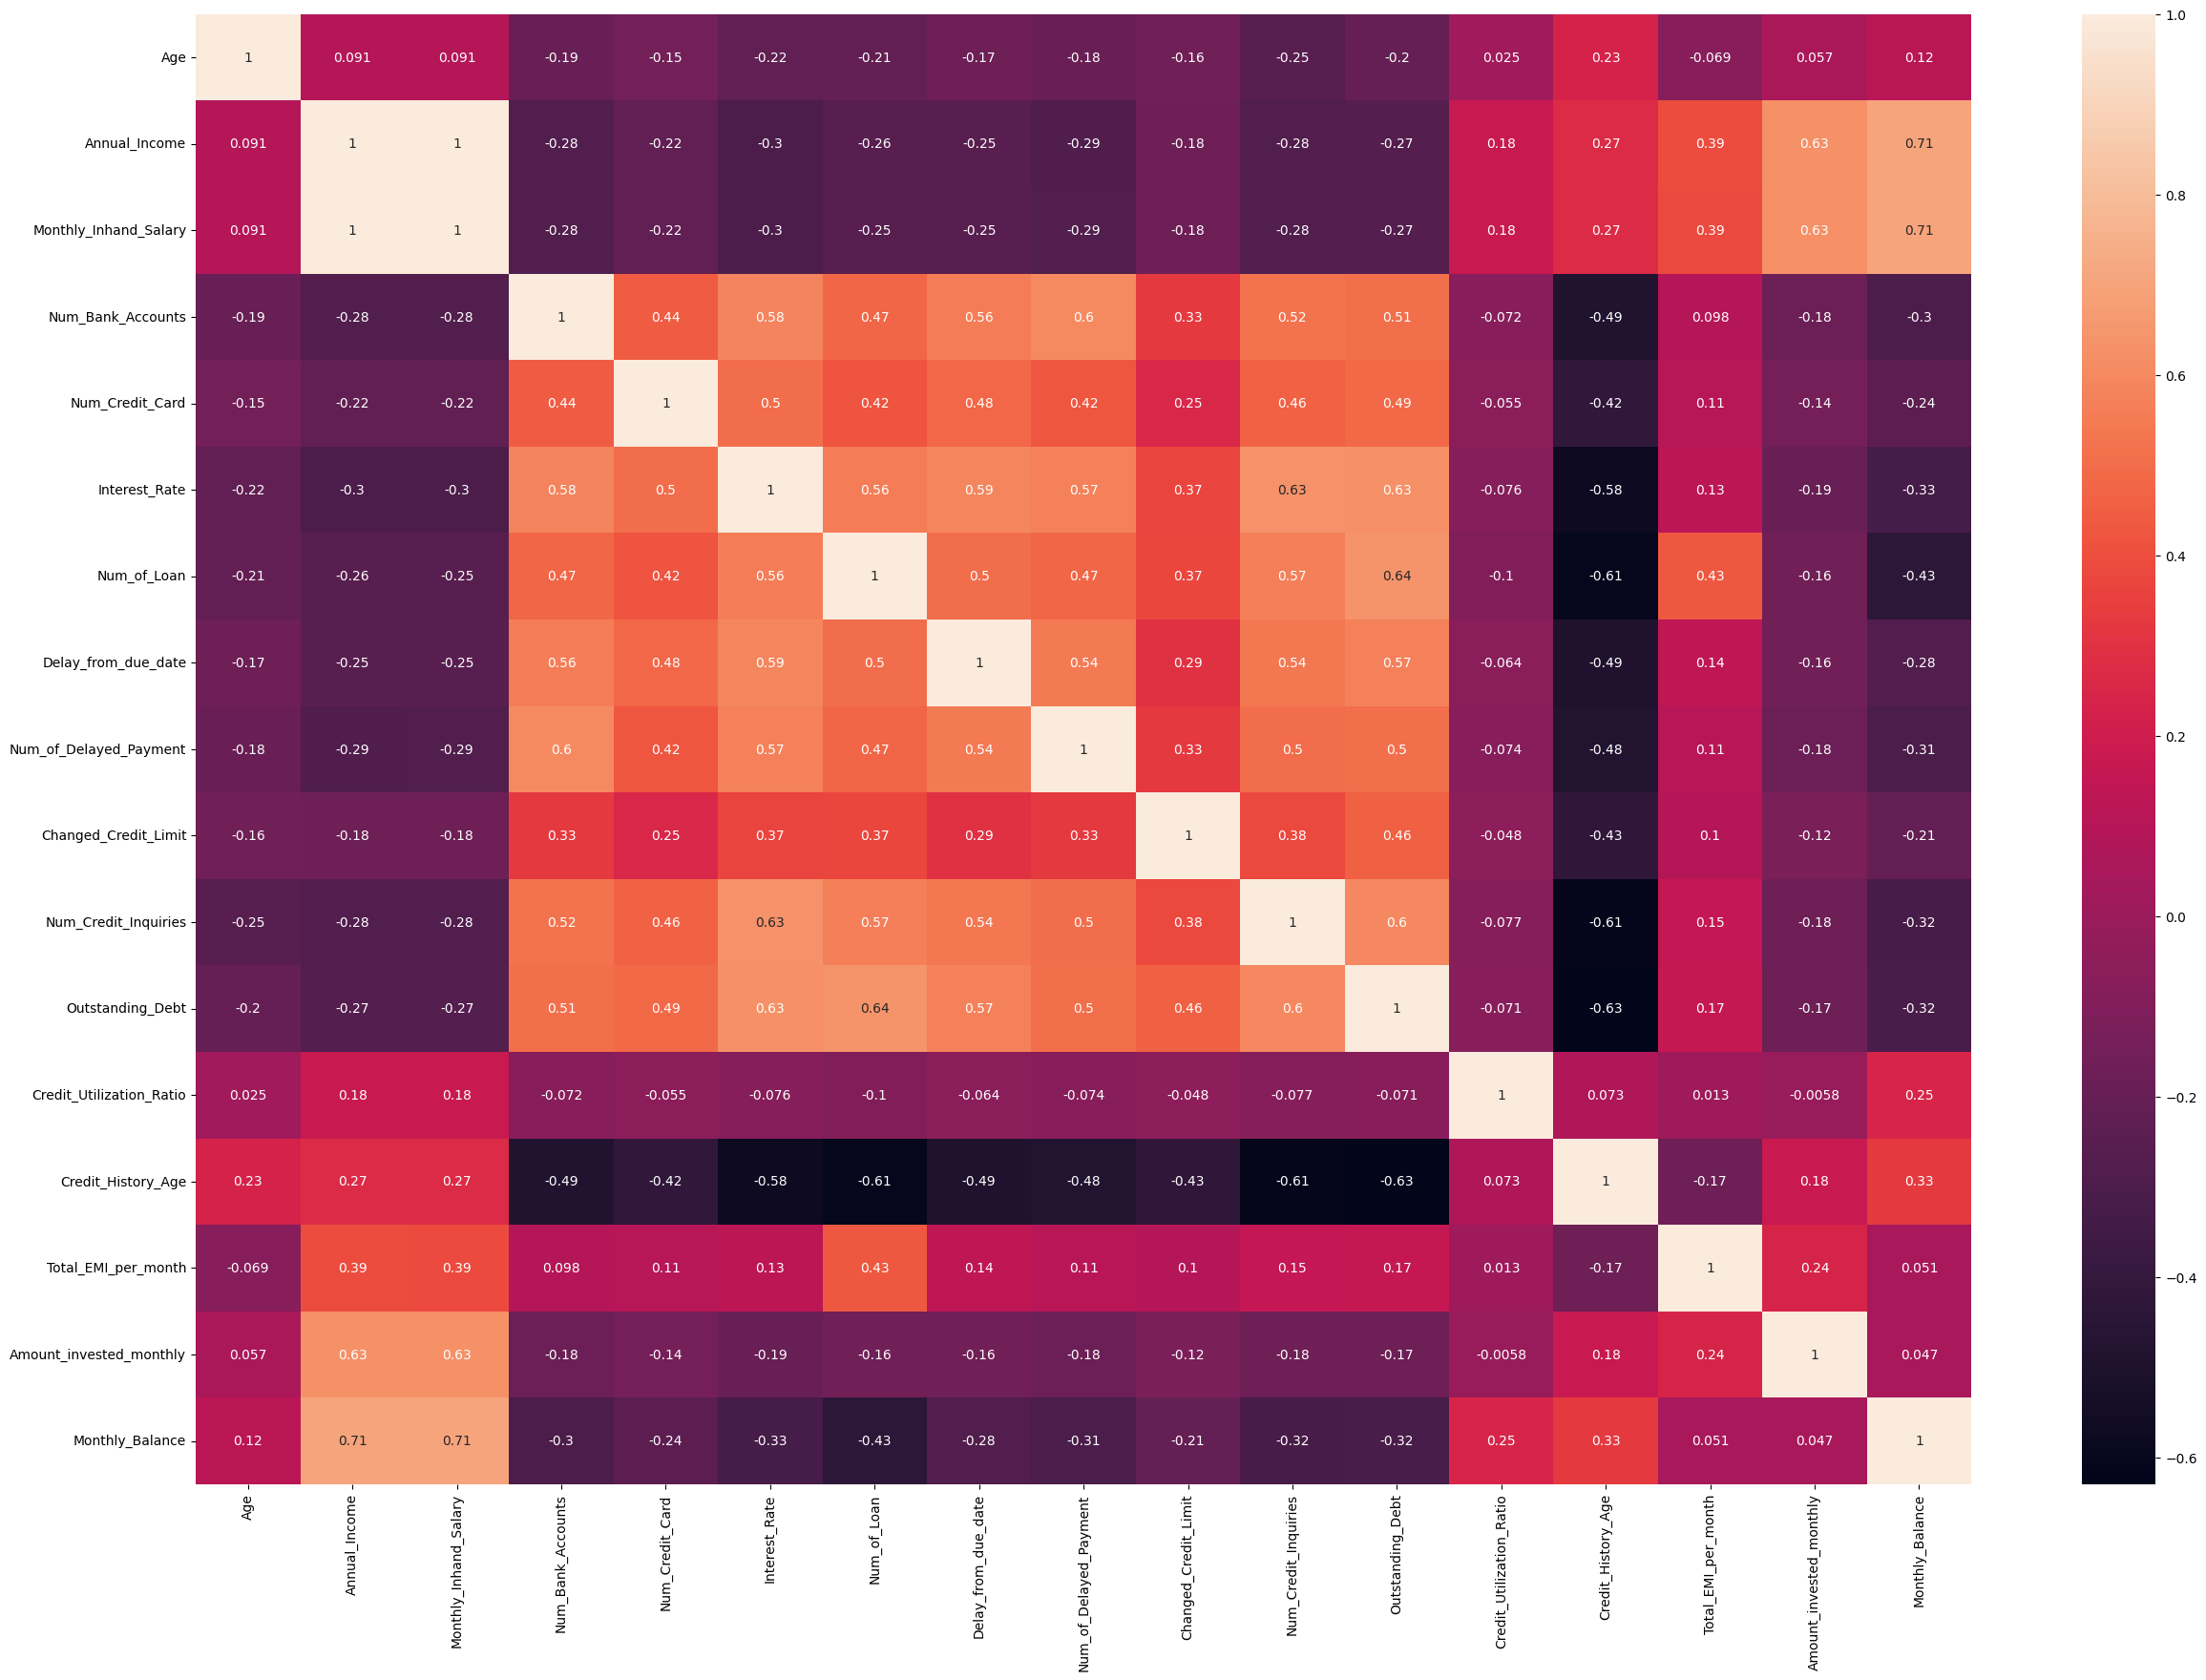

In [5]:
num_df = df.select_dtypes(include='number')
plt.figure(figsize=(30,20))
sns.heatmap(num_df.corr(), annot=True);

Топ корреляции, в том числе совпадающий с матрицей:
1. Annual_Income              –  Monthly_Inhand_Salary        ρ = +0.998
2. Monthly_Inhand_Salary      –  Monthly_Balance              ρ = +0.707
3. Annual_Income              –  Monthly_Balance              ρ = +0.706

Формулируем гипотезы о зависимости переменных с переменной Credit_Score (кредитный рейтинг).
1. Credit_Score независим ни от одной переменной.
2. Credit_Score зависим от некоторых переменных.
   Для упрощения проверки возьмем переменные, которые логически должны оказывать влияние на кредитный рейтинг.
   Такими переменными будут:
   1. Occupation
   2. Credit_Mix
   3. Payment_of_Min_Amount
   4. Payment_Behaviour
   Проеврку осуществляем через критерий хи-квадрат.

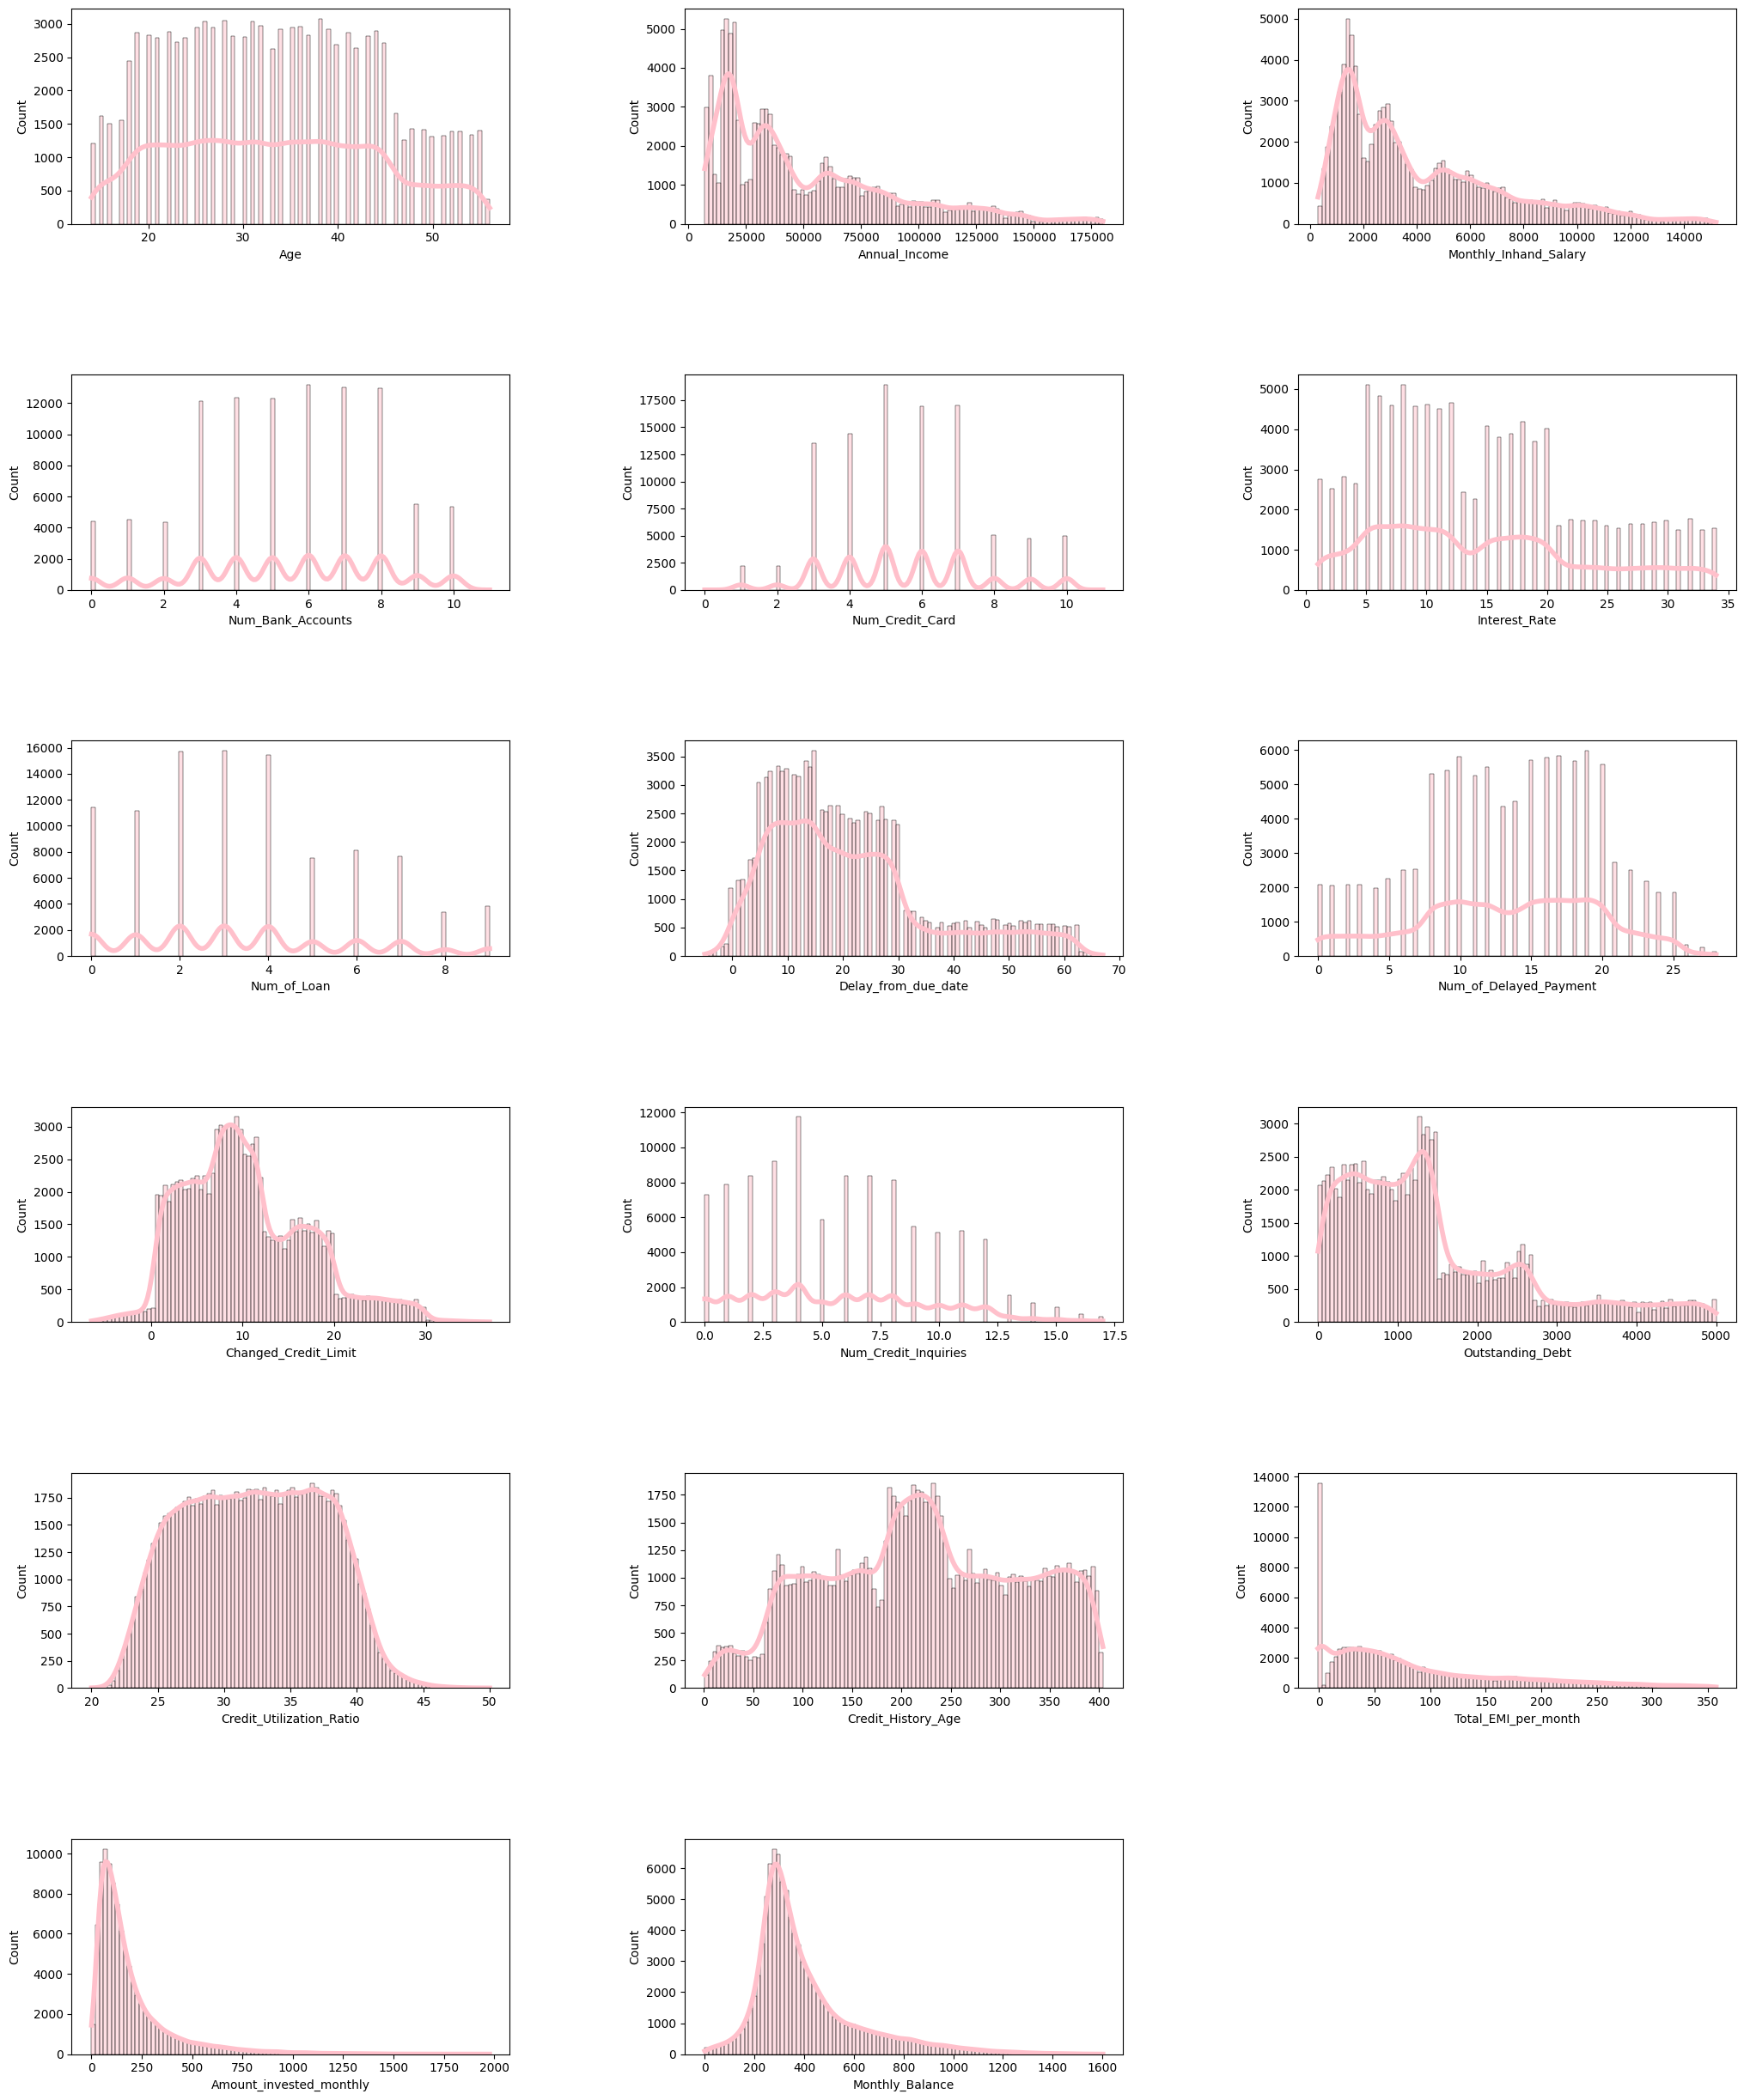

In [211]:
columns = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
           'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
           'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
           'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
           'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
length = len(columns)
plt.figure(figsize=(25, 42))

for i,j in zip(columns,range(length)):
    plt.subplot((length//2), 3, j+1)
    plt.subplots_adjust(wspace=.4, hspace=.7)
    sns.histplot(
        df[i],  
        kde=True,
        color='pink',
        bins=100,
        line_kws={'linewidth': 4, 'color': 'pink'}
        )
    #plt.title(i)
plt.show()

In [6]:
ct = pd.crosstab(df['Credit_Score'], df['Credit_Mix'])
obs = ct.values

row_sum = obs.sum(axis=1)[:, None]  # (r×1)
col_sum = obs.sum(axis=0)[None, :]  # (1×c)
N = obs.sum()
exp = row_sum * col_sum / N

chi2_stat = ((obs - exp) ** 2 / exp).sum()

r, c = obs.shape
dof = (r - 1) * (c - 1)

def chi2_pvalue_even_k(x, k):
    m = k // 2
    term = 1.0
    acc  = term
    for i in range(1, m):
        term *= x / (2 * i)
        acc  += term
    return math.exp(-x / 2) * acc

p_value = chi2_pvalue_even_k(chi2_stat, dof)

print(f"χ² = {chi2_stat:.1f},  dof = {dof},  p-value = {p_value:.4g}")
if p_value < 0.05:
    print("зависимы")
else:
    print("независимы")

χ² = 40489.4,  dof = 4,  p-value = 0
зависимы


In [7]:
#для Occupation
ct = pd.crosstab(df['Credit_Score'], df['Occupation'])
obs = ct.values

row_sum = obs.sum(axis=1)[:, None]  # (r×1)
col_sum = obs.sum(axis=0)[None, :]  # (1×c)
N = obs.sum()
exp = row_sum * col_sum / N

chi2_stat = ((obs - exp) ** 2 / exp).sum()

r, c = obs.shape
dof = (r - 1) * (c - 1)

def chi2_pvalue_even_k(x, k):
    m = k // 2
    term = 1.0
    acc  = term
    for i in range(1, m):
        term *= x / (2 * i)
        acc  += term
    return math.exp(-x / 2) * acc

p_value = chi2_pvalue_even_k(chi2_stat, dof)

print(f"χ² = {chi2_stat:.1f},  dof = {dof},  p-value = {p_value:.4g}")
if p_value < 0.05:
    print("зависимы")
else:
    print("независимы")

χ² = 180.7,  dof = 28,  p-value = 2.907e-24
зависимы


In [8]:
#для Payment_of_Min_Amount
ct = pd.crosstab(df['Credit_Score'], df['Payment_of_Min_Amount'])
obs = ct.values

row_sum = obs.sum(axis=1)[:, None]
col_sum = obs.sum(axis=0)[None, :]
N = obs.sum()
exp = row_sum * col_sum / N

chi2_stat = ((obs - exp) ** 2 / exp).sum()

r, c = obs.shape
dof = (r - 1) * (c - 1)

def chi2_pvalue_even_k(x, k):
    m = k // 2
    term = 1.0
    acc  = term
    for i in range(1, m):
        term *= x / (2 * i)
        acc  += term
    return math.exp(-x / 2) * acc

p_value = chi2_pvalue_even_k(chi2_stat, dof)

print(f"χ² = {chi2_stat:.1f},  dof = {dof},  p-value = {p_value:.4g}")
if p_value < 0.05:
    print("зависимы")
else:
    print("независимы")

χ² = 22420.4,  dof = 2,  p-value = 0
зависимы


In [9]:
#для Payment_Behaviour
ct = pd.crosstab(df['Credit_Score'], df['Payment_Behaviour'])
obs = ct.values

row_sum = obs.sum(axis=1)[:, None]
col_sum = obs.sum(axis=0)[None, :]
N = obs.sum()
exp = row_sum * col_sum / N

chi2_stat = ((obs - exp) ** 2 / exp).sum()

r, c = obs.shape
dof = (r - 1) * (c - 1)

def chi2_pvalue_even_k(x, k):
    m = k // 2
    term = 1.0
    acc  = term
    for i in range(1, m):
        term *= x / (2 * i)
        acc  += term
    return math.exp(-x / 2) * acc

p_value = chi2_pvalue_even_k(chi2_stat, dof)

print(f"χ² = {chi2_stat:.1f},  dof = {dof},  p-value = {p_value:.4g}")
if p_value < 0.05:
    print("зависимы")
else:
    print("независимы")

χ² = 1645.9,  dof = 10,  p-value = 0
зависимы


После проверки нулевая гипотеза не принимается во всех случаях. Значит, Credit_Score зависим от всех выбранных переменных.
Далее посмотрим наиболее сильную зависимость с Credit_Score у всех переменных (которые уже были выбраны до этого).

Далее разобьем на категории, насколько сильные связи зависимости.

In [10]:
def cramers_v_and_chi2(x, y):
    ct = pd.crosstab(x, y)
    obs = ct.values
    n = obs.sum()
    row_tot = obs.sum(axis=1).reshape(-1, 1)
    col_tot = obs.sum(axis=0).reshape(1, -1)
    exp = row_tot.dot(col_tot) / n

    chi2 = ((obs - exp)**2 / exp).sum()
    r, c = obs.shape
    v = math.sqrt(chi2 / (n * min(r-1, c-1)))
    return chi2, v


In [11]:
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
results = []
for col in cat_cols:
    chi2, v = cramers_v_and_chi2(df[col], df['Credit_Score'])
    if v >= 0.3:
        strength = 'сильное'
    elif v >= 0.1:
        strength = 'умеренное'
    else:
        strength = 'слабое'
    results.append({
        'Переменная': col,
        'Chi2': round(chi2,1),
        "Cramer's V": round(v,3),
        'Влияние': strength
    })

res_df = pd.DataFrame(results).set_index('Переменная')
print(res_df.to_string())

                          Chi2  Cramer's V  Влияние
Переменная                                         
Occupation               180.7       0.030   слабое
Credit_Mix             40489.4       0.450  сильное
Payment_of_Min_Amount  22420.4       0.474  сильное
Payment_Behaviour       1645.9       0.091   слабое


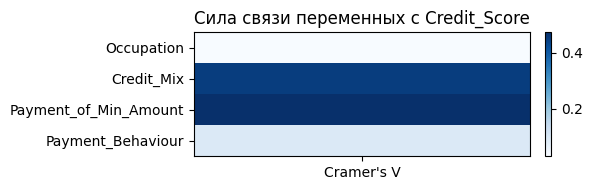

In [219]:
plt.figure(figsize=(6,2))
heat = plt.imshow(res_df[["Cramer's V"]], cmap='Blues', aspect='auto')
plt.colorbar(heat, fraction=0.046, pad=0.04)
plt.yticks(range(len(res_df)), res_df.index)
plt.xticks([0], ["Cramer's V"])
plt.title("Сила связи переменных с Credit_Score")
plt.tight_layout()
plt.show()

In [ ]:
Вывод: самая сильная зависимость у Credit_Mix и Payment_of_Min_Amount.

Однородность.
Будем рассматривать однородность переменных опять же по Credit_Score.
Для проверки выбраны переменные, которые снова могут в теории повлиять на кредитный рейтинг.
Это:
1. Credit_Mix.
2. Payment_Behaviour.
3. Num_Credit_Card.
4. Credit_History_Age.
5. Num_of_Loan.
6. Monthly_Inhand_Salary.
7. Age.
8. Num_of_Delayed_Payment.
9. Interest_Rate.
10. Annual_Income.
11. Credit_Utilization_Ratio.

In [229]:
def countplot_with_perc(x, data, hue):
    ax         = sns.countplot(x=x, data=data, hue=hue);
    bars       = ax.patches
    half       = int(len(bars)/2-1)
    left_bars  = bars[:half]
    right_bars = bars[half:]
    for left, right in zip(left_bars, right_bars):
        height_l = left.get_height()
        height_r = right.get_height()
        total    = height_l + height_r
        #ax.text(left.get_x() + left.get_width()/2.,
        #    height_l + 40, '{0:.0%}'.format(height_l/total), ha='center');
        #ax.text(right.get_x() + right.get_width()/2.,
        #    height_r + 40, '{0:.0%}'.format(height_r/total), ha='center');

def histplot_continuous(x, data, hue):
    sns.histplot(data=data, x=x, hue=hue,
        kde=True, bins=15, palette='tab10', multiple='stack', line_kws={'lw': 5});

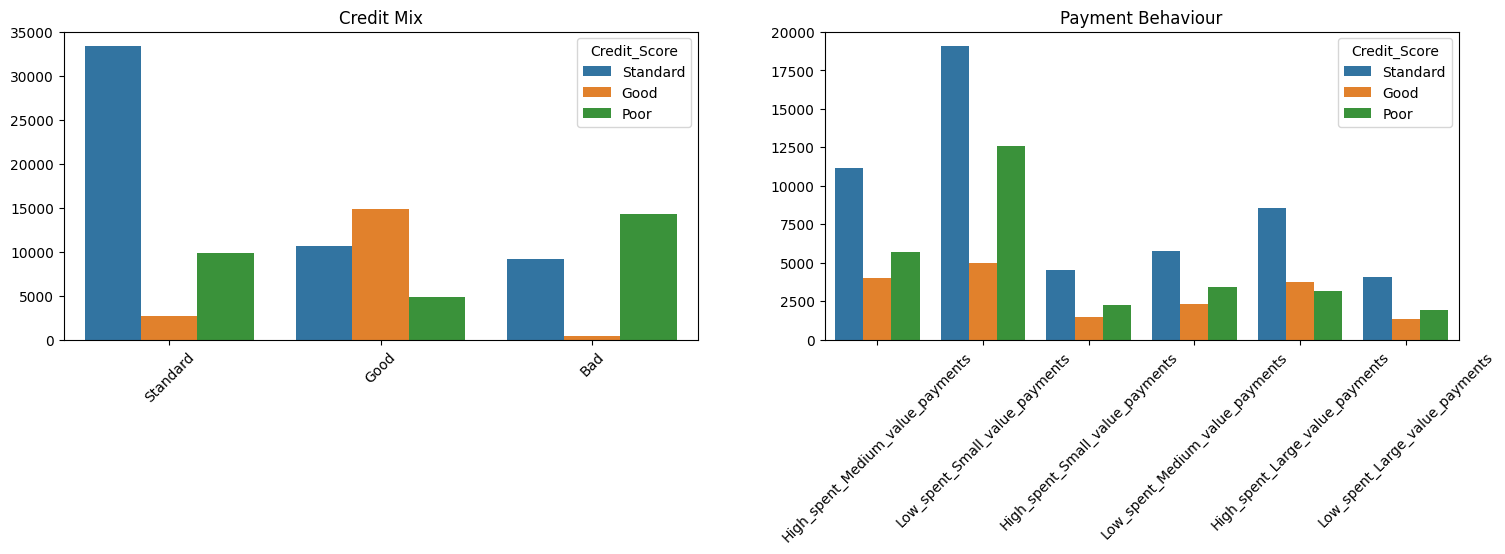

In [230]:
plt.figure(figsize=(18, 4))

n_row = 1
n_col = 2
hue   = 'Credit_Score'
#------------------------------------------------------------------------------------------

plt.subplot(n_row, n_col, 1)
countplot_with_perc(x='Credit_Mix', data=df, hue=hue)
plt.title('Credit Mix')
plt.xticks(rotation=45)
plt.ylabel(None)
plt.xlabel(None)

#------------------------------------------------------------------------------------------
plt.subplot(n_row, n_col, 2)
countplot_with_perc(x='Payment_Behaviour', data=df, hue=hue)
plt.title('Payment Behaviour')
plt.xticks(rotation=45)
plt.ylabel(None)
plt.xlabel(None)
#
plt.show()

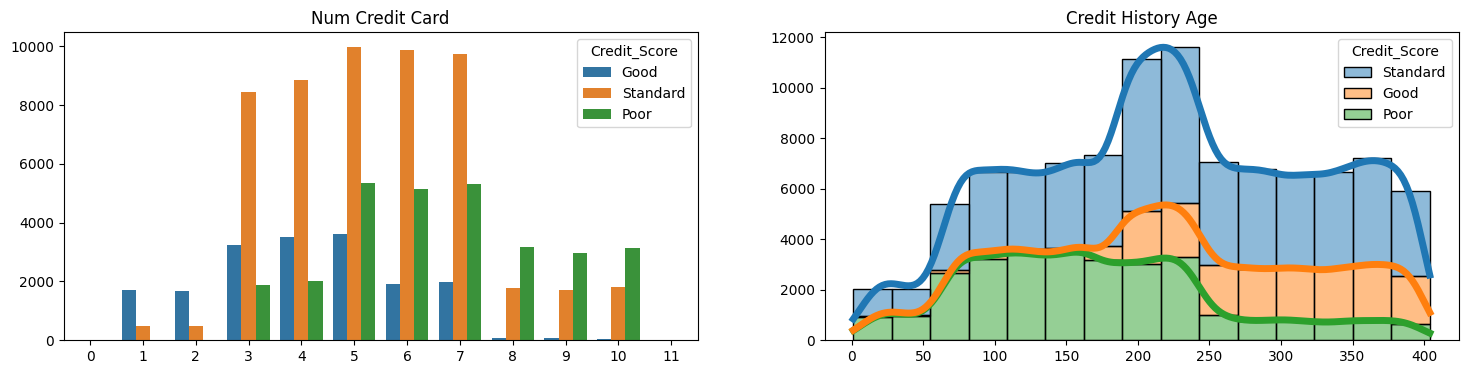

In [231]:
plt.figure(figsize=(18, 4))

n_row = 1
n_col = 2
hue   = 'Credit_Score'

#------------------------------------------------------------------------------------------
plt.subplot(n_row, n_col, 1)
countplot_with_perc(x='Num_Credit_Card', data=df, hue=hue)
plt.title('Num Credit Card')
plt.ylabel(None)
plt.xlabel(None)

#------------------------------------------------------------------------------------------
plt.subplot(n_row, n_col, 2)
histplot_continuous(x='Credit_History_Age', data=df, hue=hue)
plt.title('Credit History Age')
plt.ylabel(None)
plt.xlabel(None)
#
plt.show()

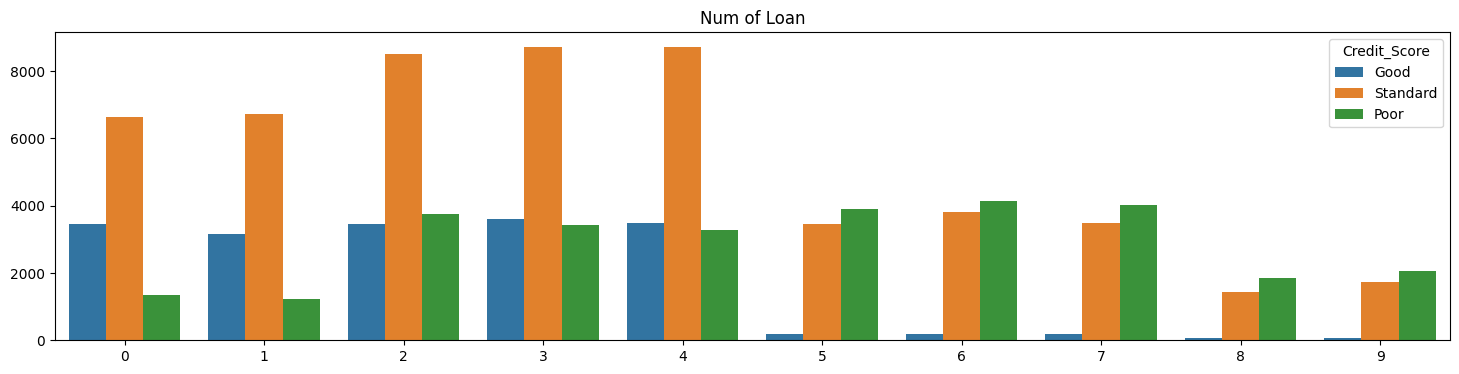

In [232]:
plt.figure(figsize=(18, 4))

n_row = 1
n_col = 1
hue   = 'Credit_Score'

#------------------------------------------------------------------------------------------
plt.subplot(n_row, n_col, 1)
countplot_with_perc(x='Num_of_Loan', data=df, hue=hue)
plt.title('Num of Loan')
plt.ylabel(None)
plt.xlabel(None)
#------------------------------------------------------------------------------------------
#plt.subplot(n_row, n_col, 2)
#histplot_continuous(x='Monthly_Inhand_Salary', data=df, hue=hue)
#plt.title('Monthly Inhand Salary')
#plt.ylabel(None)
#plt.xlabel(None)
#
plt.show()

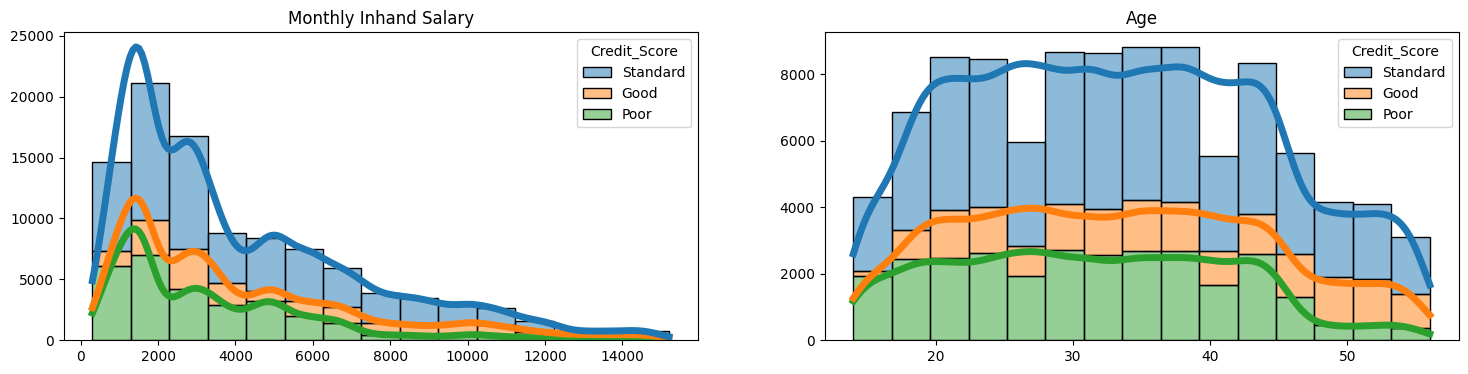

In [233]:
plt.figure(figsize=(18, 4))

n_row = 1
n_col = 2
hue   = 'Credit_Score'

plt.subplot(n_row, n_col, 1)
histplot_continuous(x='Monthly_Inhand_Salary', data=df, hue=hue)
plt.title('Monthly Inhand Salary')
plt.ylabel(None)
plt.xlabel(None)


plt.subplot(n_row, n_col, 2)
histplot_continuous(x='Age', data=df, hue=hue)
plt.title('Age')
plt.ylabel(None)
plt.xlabel(None)


plt.show()

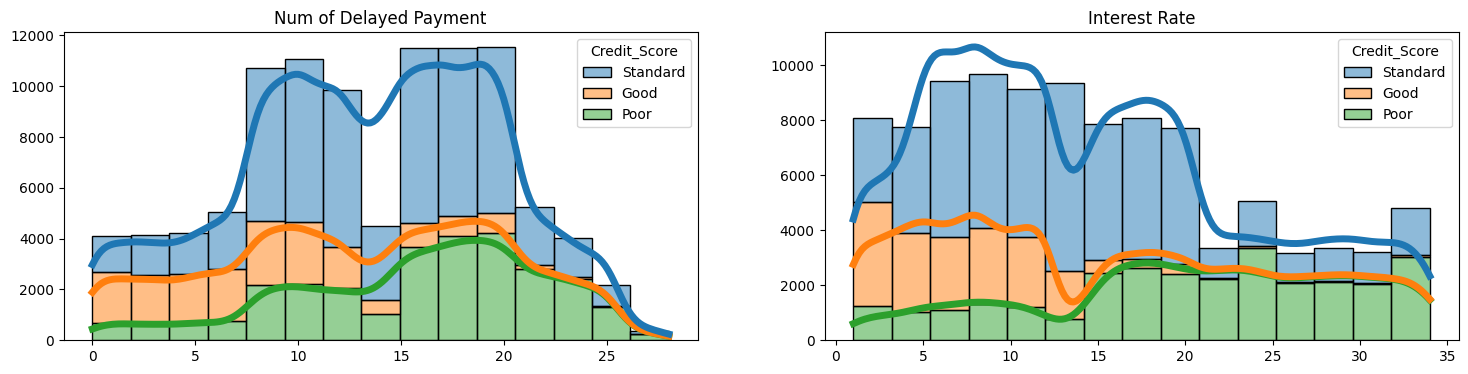

In [234]:
plt.figure(figsize=(18, 4))

n_row = 1
n_col = 2
hue   = 'Credit_Score'

plt.subplot(n_row, n_col, 1)
histplot_continuous(x='Num_of_Delayed_Payment', data=df, hue=hue)
plt.title('Num of Delayed Payment')
plt.ylabel(None)
plt.xlabel(None)


plt.subplot(n_row, n_col, 2)
histplot_continuous(x='Interest_Rate', data=df, hue=hue)
plt.title('Interest Rate')
plt.ylabel(None)
plt.xlabel(None)


plt.show()

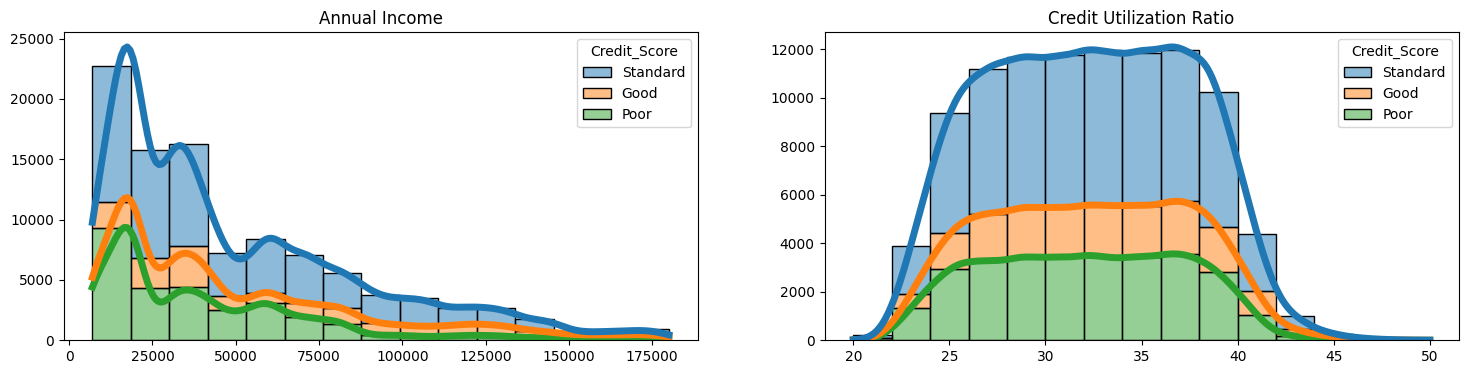

In [235]:
plt.figure(figsize=(18, 4))

n_row = 1
n_col = 2
hue   = 'Credit_Score'

plt.subplot(n_row, n_col, 1)
histplot_continuous(x='Annual_Income', data=df, hue=hue)
plt.title('Annual Income')
plt.ylabel(None)
plt.xlabel(None)

plt.subplot(n_row, n_col, 2)
histplot_continuous(x='Credit_Utilization_Ratio', data=df, hue=hue)
plt.title('Credit Utilization Ratio')
plt.ylabel(None)
plt.xlabel(None)

plt.show()

После делаем еще одну проверку на силу зависимости. Благодаря проверке на однородность выделяем нужные переменные:
1. Annual_Income.
2. Monthly_Inhand_Salary.
3. Age.
4. Num_of_Delayed_Payment.
5. Credit_Utilization_Ratio.

In [12]:
def cramers_v_and_chi2(x, y):
    ct = pd.crosstab(x, y)
    obs = ct.values
    n = obs.sum()
    row_tot = obs.sum(axis=1).reshape(-1, 1)
    col_tot = obs.sum(axis=0).reshape(1, -1)
    exp = row_tot.dot(col_tot) / n
    
    chi2 = ((obs - exp)**2 / exp).sum()
    
    r, c = obs.shape
    v = math.sqrt(chi2 / (n * min(r-1, c-1)))
    return chi2, v

cat_cols = ['Annual_Income', 'Monthly_Inhand_Salary', 'Age', 'Num_of_Delayed_Payment', 'Credit_Utilization_Ratio']

results = []
for col in cat_cols:
    chi2, v = cramers_v_and_chi2(df[col], df['Credit_Score'])
    if v >= 0.3:
        strength = 'сильное'
    elif v >= 0.1:
        strength = 'умеренное'
    else:
        strength = 'слабое'
    results.append({
        'Переменная': col,
        'Chi2': round(chi2,1),
        "Cramer's V": round(v,3),
        'Влияние': strength
    })

res_df = pd.DataFrame(results).set_index('Переменная')
print(res_df.to_string())

                              Chi2  Cramer's V    Влияние
Переменная                                               
Annual_Income             133623.4       0.817    сильное
Monthly_Inhand_Salary     135893.7       0.824    сильное
Age                         4831.0       0.155  умеренное
Num_of_Delayed_Payment     18924.0       0.308    сильное
Credit_Utilization_Ratio  200000.0       1.000    сильное


Вывод: сильная зависимость по хи-квадрату и Крамеру есть у Annual_Income, Monthly_Inhand_Salary, Num_of_Delayed_Payment, Credit_Utilization_Ratio. Таким образом, переменная Age, хоть и имеет умеренное влияние, однако не влияет на кредитный рейтинг настолько сильно, как остальные. Соответственно, для предсказания рейтинга возраст не сильно поможет.

Выполняем проверку на однородность дисперсий у переменных.

In [13]:
def f(groups):
    medians = [np.median(g) for g in groups]
    deviations = [np.abs(g - m) for g, m in zip(groups, medians)]
    #ANOVA
    all_deviations = np.concatenate(deviations)
    grand_mean = all_deviations.mean()
    
    ss_between = sum(len(d)*(np.mean(d) - grand_mean)**2 for d in deviations)
    ss_within = sum(((d - np.mean(d))**2).sum() for d in deviations)
    
    df_between = len(groups) - 1
    df_within = len(all_deviations) - len(groups)
    ms_between = ss_between / df_between
    ms_within = ss_within / df_within
    F = ms_between / ms_within
    return F


In [14]:
def test_homogeneity_of_variances(df, group_col, var_col):
    groups = [g[var_col].dropna().values for _, g in df.groupby(group_col)]
    
    F_levene = f(groups)
        
    print(f"\nПроверка на однородность дисперсий: {var_col} по {group_col}")
    print(f"Levene: F = {F_levene:.3f}")
    if F_levene > 1:
        print("неоднородны")
    else:
        print("однородны")
test_homogeneity_of_variances(df, group_col='Credit_Score', var_col='Annual_Income')

test_homogeneity_of_variances(df, group_col='Credit_Score', var_col='Credit_Utilization_Ratio')


Проверка на однородность дисперсий: Annual_Income по Credit_Score
Levene: F = 1309.991
неоднородны

Проверка на однородность дисперсий: Credit_Utilization_Ratio по Credit_Score
Levene: F = 8.409
неоднородны


Вывод:
1. Annual_Income по Credit_Score неоднородны.
2. Credit_Utilization_Ratio по Credit_Score неоднородны.

In [15]:
df['Credit_Score_Encoded'] = df['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})
df['Credit_Score_Binary'] = df['Credit_Score'].apply(lambda x: 1 if x == 'Good' else 0)

numeric_cols = ['Age', 'Annual_Income', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age']
desc = df[numeric_cols].describe()

#нормальность
shapiro_results = []
for var in numeric_cols:
    sample = df[var].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    stat, p = stats.shapiro(sample)
    shapiro_results.append({'Variable': var, 'W': stat, 'p-value': p})
shapiro_df = pd.DataFrame(shapiro_results)

#однородность
groups_income = [grp['Annual_Income'].dropna().values for _, grp in df.groupby('Occupation') if len(grp) > 20]
anova_stat, anova_p = stats.f_oneway(*groups_income)
kw_stat, kw_p = stats.kruskal(*groups_income)

groups_util = [grp['Credit_Utilization_Ratio'].dropna().values for _, grp in df.groupby('Payment_of_Min_Amount')]
levene_stat, levene_p = stats.levene(*groups_util)
fligner_stat, fligner_p = stats.fligner(*groups_util)

homogeneity = pd.DataFrame([
    {'Test': 'ANOVA Income~Occupation', 'Statistic': anova_stat, 'p-value': anova_p},
    {'Test': 'Kruskal Income~Occupation', 'Statistic': kw_stat, 'p-value': kw_p},
    {'Test': 'Levene Util~Payment_of_Min', 'Statistic': levene_stat, 'p-value': levene_p},
    {'Test': 'Fligner Util~Payment_of_Min', 'Statistic': fligner_stat, 'p-value': fligner_p},
])


#корреляция
pearson_corr = df[['Credit_Score_Encoded', 'Annual_Income', 'Credit_Utilization_Ratio']].corr(method='pearson')
spearman_corr = df[['Credit_Score_Encoded', 'Annual_Income', 'Credit_Utilization_Ratio']].corr(method='spearman')


#линейная регрессия
ols_model = smf.ols('Credit_Score_Encoded ~ Annual_Income + Credit_Utilization_Ratio', data=df).fit()
print(ols_model.summary())

#логистическая
logit_model = smf.logit('Credit_Score_Binary ~ Annual_Income + Credit_Utilization_Ratio', data=df).fit(disp=False)
print(logit_model.summary())


                             OLS Regression Results                             
Dep. Variable:     Credit_Score_Encoded   R-squared:                       0.045
Model:                              OLS   Adj. R-squared:                  0.045
Method:                   Least Squares   F-statistic:                     2371.
Date:                  Mon, 19 May 2025   Prob (F-statistic):               0.00
Time:                          16:58:03   Log-Likelihood:            -1.0029e+05
No. Observations:                100000   AIC:                         2.006e+05
Df Residuals:                     99997   BIC:                         2.006e+05
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Inte

In [16]:
y = df['Num_Credit_Card']
x = df[['Interest_Rate']]
df

,Customer_ID,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Last_Loan_7,Last_Loan_6,Last_Loan_5,Last_Loan_4,Last_Loan_3,Last_Loan_2,Last_Loan_1,Credit_Score,Credit_Score_Encoded,Credit_Score_Binary
0,CUS_0x98ed,31,Journalist,22229.060,1672.421667,6,4,5.0,3,10,...,No Loan,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Debt Consolidation Loan,Standard,1,0
1,CUS_0x36b4,43,Musician,17060.705,1685.725417,8,3,11.0,4,24,...,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Auto Loan,Auto Loan,Standard,1,0
2,CUS_0x105b,24,Accountant,34428.210,2575.017500,2,4,8.0,0,3,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Good,2,1
3,CUS_0x4c4a,21,Accountant,12613.920,1155.160000,4,6,13.0,3,14,...,No Loan,No Loan,No Loan,No Loan,Personal Loan,Student Loan,Home Equity Loan,Standard,1,0
4,CUS_0x612f,31,Journalist,34775.160,3048.930000,7,9,25.0,5,20,...,No Loan,No Loan,Auto Loan,Mortgage Loan,Auto Loan,Payday Loan,Not Specified,Poor,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0xc52a,46,Writer,35032.660,2853.388333,10,6,33.0,7,48,...,Credit-Builder Loan,Student Loan,Personal Loan,Mortgage Loan,Payday Loan,Payday Loan,Student Loan,Poor,0,0
99996,CUS_0x83cc,34,Engineer,125047.240,10682.603333,2,5,9.0,0,11,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Standard,1,0
99997,CUS_0x6ae6,26,Lawyer,9045.485,644.664842,8,7,20.0,6,52,...,No Loan,Not Specified,Student Loan,Auto Loan,Not Specified,Student Loan,Auto Loan,Poor,0,0
99998,CUS_0x6f0c,20,Lawyer,53564.880,4207.740000,5,3,13.0,2,6,...,No Loan,No Loan,No Loan,No Loan,No Loan,Mortgage Loan,Personal Loan,Standard,1,0


Предсказание кредитного рейтинга.
Выбранные переменные, по которым будет вестись предсказание:
1. Interest_Rate
2. Num_of_Delayed_Payment
3. Num_of_Loan
4. Num_Bank_Accounts
5. Delay_from_due_date

C:\Users\catso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Explained variance ratio (PCA): [0.63718824 0.11391881 0.09177295 0.07966397 0.07745603]
Number of components chosen: 5

Classification report:
              precision    recall  f1-score   support

        Good       0.52      0.32      0.40     17828
        Poor       0.63      0.45      0.52     28998
    Standard       0.61      0.78      0.68     53174

    accuracy                           0.60    100000
   macro avg       0.58      0.52      0.53    100000
weighted avg       0.60      0.60      0.59    100000



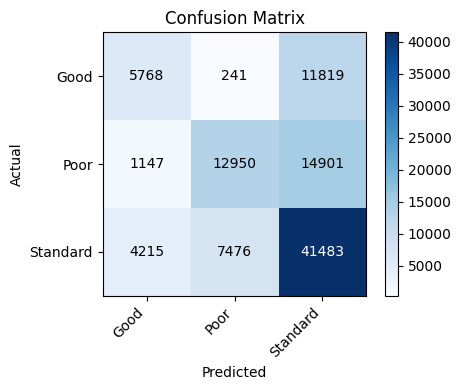

In [25]:
df = pd.read_csv('Credit_score_cleaned_data.csv')
df = df.dropna(subset=[
    'Credit_Score',
    'Interest_Rate',
    'Num_of_Delayed_Payment',
    'Num_of_Loan',
    'Num_Bank_Accounts',
    'Delay_from_due_date',
])

le = LabelEncoder()
y = le.fit_transform(df['Credit_Score'])

features = [
    'Interest_Rate',
    'Num_of_Delayed_Payment',
    'Num_of_Loan',
    'Num_Bank_Accounts',
    'Delay_from_due_date',
]
X = df[features].values

pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('pca',   PCA(n_components=0.95, svd_solver='full')),
    ('clf',   LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000))
])

pipeline.fit(X, y)
y_pred = pipeline.predict(X)

print("Explained variance ratio (PCA):", pipeline.named_steps['pca'].explained_variance_ratio_)
print("Number of components chosen:", pipeline.named_steps['pca'].n_components_)
print("\nClassification report:")
print(classification_report(y, y_pred, target_names=le.classes_))

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Blues')
ax.figure.colorbar(im, ax=ax)
classes = le.classes_
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

Стандартный рейтинг предсказывается лучше всего, в то время как хороший рейтинг — хуже всего.
На выбранных данных accuracy = 0.60

Сравним однофакторную и многофакторную модели, чтобы выявить переменные, которые оказывают полодительное влияние на предсказание кредитного рейтинга.
Выберем новые переменные, от которых, как уже было выявлено, зависим Credit_Score. Это:
1. Payment_of_Min_Amount
2. Annual_Income
3. Credit_History_Age
4. щдшююб

C:\Users\catso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Однофакторная модель
Accuracy = 0.529

Confusion Matrix:
Predicted  Poor  Standard
Actual                   
Good        315     17513
Poor       6137     22861
Standard   6444     46730 



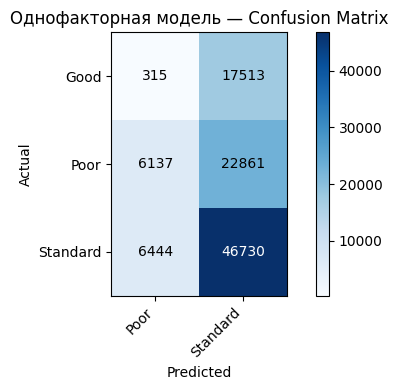

C:\Users\catso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Многофакторная модель
Accuracy = 0.532

Confusion Matrix:
Predicted  Good  Poor  Standard
Actual                         
Good        766   363     16699
Poor        285  7926     20787
Standard   1039  7582     44553 



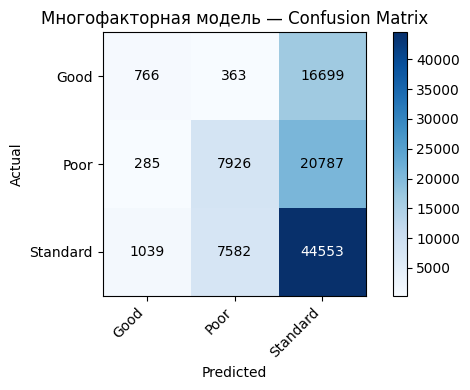

In [247]:
df = pd.read_csv('Credit_score_cleaned_data.csv')
df = df.dropna(subset=[
    'Credit_Score',
    'Payment_of_Min_Amount',
    'Annual_Income',
    'Credit_History_Age', #работает пока что лучше остальных
    'Credit_Utilization_Ratio'
])
#cat_cols = ['Annual_Income', 'Monthly_Inhand_Salary', 'Age', 'Num_of_Delayed_Payment', 'Credit_Utilization_Ratio']

le = LabelEncoder()
y = le.fit_transform(df['Credit_Score'])
me = LabelEncoder()

def train_and_report(X, y, feature_names, title):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    model = LogisticRegression(
        multi_class='multinomial', solver='lbfgs', max_iter=1000
    )
    model.fit(Xs, y)
    y_pred = model.predict(Xs)

    acc = (y_pred == y).mean()
    print(f"{title}\nAccuracy = {acc:.3f}\n")

    cm = pd.crosstab(
        pd.Series(le.inverse_transform(y), name='Actual'),
        pd.Series(le.inverse_transform(y_pred), name='Predicted'),
        rownames=['Actual'], colnames=['Predicted']
    )
    print("Confusion Matrix:")
    print(cm.to_string(), "\n")

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(cm.values, cmap='Blues', interpolation='nearest')
    fig.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(cm.columns)))
    ax.set_yticks(np.arange(len(cm.index)))
    ax.set_xticklabels(cm.columns)
    ax.set_yticklabels(cm.index)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.values.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm.values[i, j] > thresh else "black"
            ax.text(j, i, int(cm.values[i, j]), ha="center", va="center", color=color)

    ax.set_title(f"{title} — Confusion Matrix")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

train_and_report(
    #X=df[['Num_of_Delayed_Payment']].values,
    X=df[['Outstanding_Debt']].values,
    y=y,
    #feature_names=['Num_of_Delayed_Payment'],
    feature_names=['Outstanding_Debt'],

    title='Однофакторная модель'
)
#Occupation               180.7       0.030   слабое
#Credit_Mix             40489.4       0.450  сильное
#Payment_of_Min_Amount  22420.4       0.474  сильное
#Payment_Behaviour       1645.9       0.091   слабое

features = [
    'Annual_Income',
    'Credit_History_Age', #работает пока что лучше остальных
    'Credit_Utilization_Ratio'
]
#Num_Of_Loan, Num_of_Delayed_Payment, Num_Bank_Accounts, Delay_from_due_date хорош в poor
train_and_report(
    X=df[features].values,
    y=y,
    feature_names=features,
    title='Многофакторная модель'
)

Можно сделать следующий вывод: с Credit_History_Age работает пока что лучше всего. В однофакторной модели вообще не предсказывается хороший рейтинг. В многофакторной стандартный предсказывается хорошо, плохой — хуже, а хороший рейтинг вновь предсказывается очень плохо. В данной ситуации accuracy не больше 0.532

Рассматриваем больше переменных и надеемся, что это поможет.
1. Annual_Income
2. Credit_Mix
3. Age
4. Outstanding_Debt
5. Credit_History_Age
6. Payment_of_Min_Amount
7. Payment_Behaviour
8. Monthly_Inhand_Salary
   Берем все переменные, у которых самое сильное влияние на Credit_Score.

Accuracy: 0.6636333333333333
              precision    recall  f1-score   support

        Good       0.49      0.84      0.62      5349
        Poor       0.71      0.51      0.60      8699
    Standard       0.75      0.69      0.72     15952

    accuracy                           0.66     30000
   macro avg       0.65      0.68      0.64     30000
weighted avg       0.69      0.66      0.66     30000



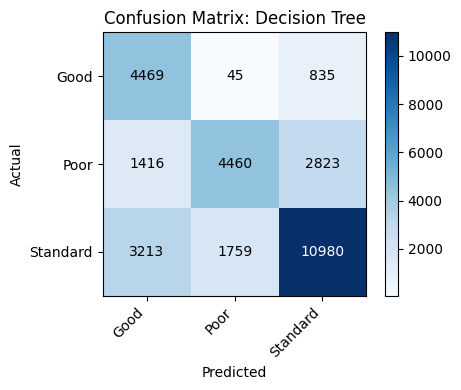

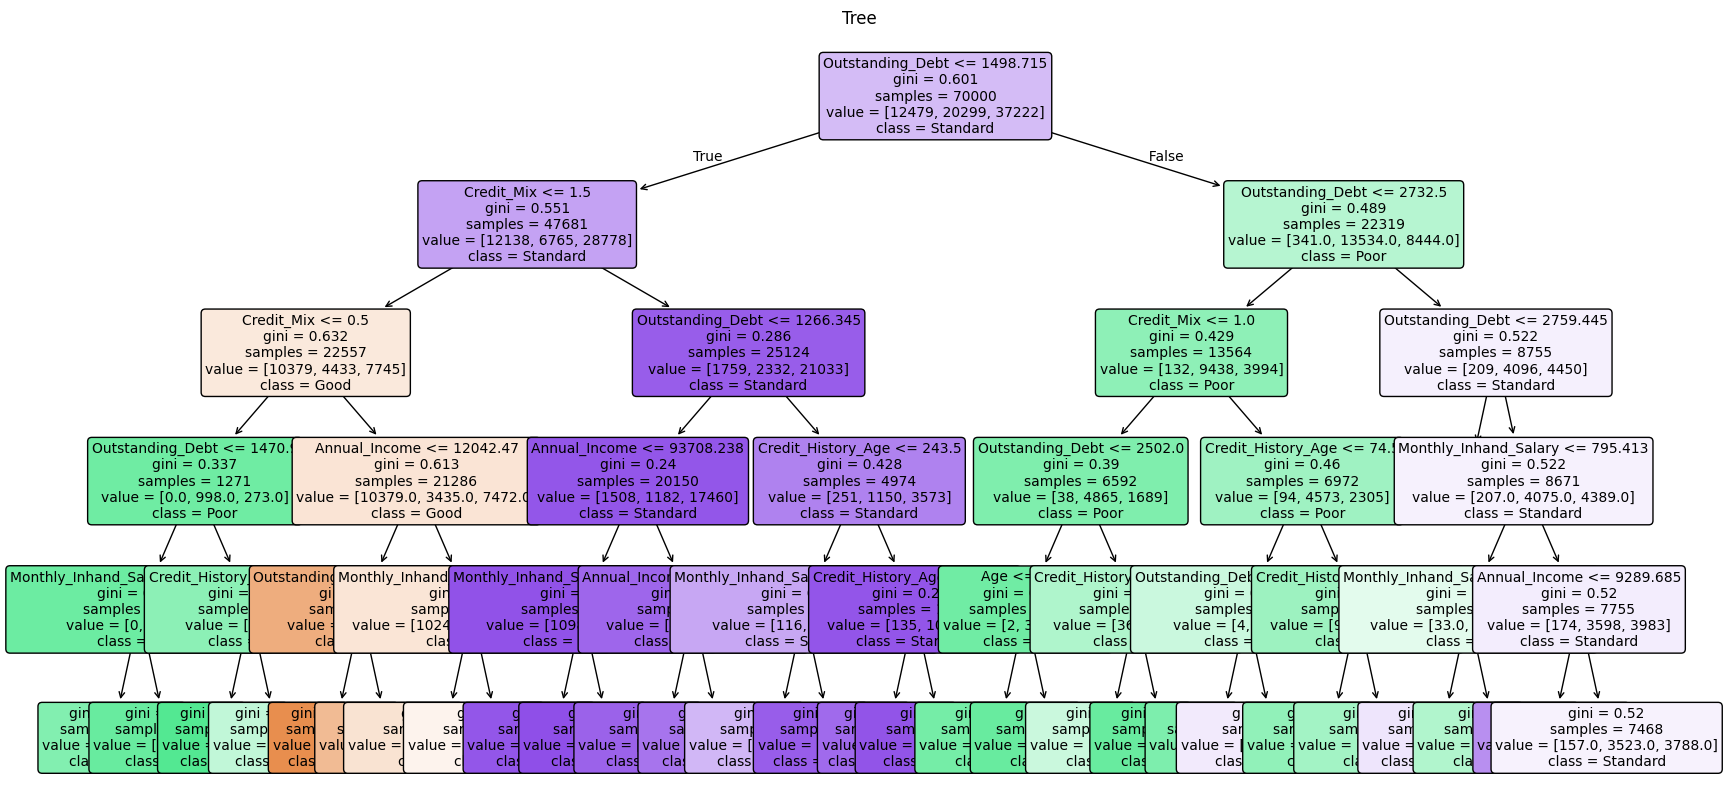

  Annual_Income: 0.006
  Credit_Mix: 0.480
  Age: 0.000
  Outstanding_Debt: 0.488
  Credit_History_Age: 0.018
  Payment_of_Min_Amount: 0.000
  Payment_Behaviour: 0.000
  Monthly_Inhand_Salary: 0.007


In [248]:
df = pd.read_csv('Credit_score_cleaned_data.csv')

labelEncoder_X = LabelEncoder()

df['Occupation'] = labelEncoder_X.fit_transform(df['Occupation'])
df['Credit_Mix'] = labelEncoder_X.fit_transform(df['Credit_Mix'])
df['Payment_of_Min_Amount'] = labelEncoder_X.fit_transform(df['Payment_of_Min_Amount'])
df['Payment_Behaviour'] = labelEncoder_X.fit_transform(df['Payment_Behaviour'])
df['Last_Loan_9'] = labelEncoder_X.fit_transform(df['Last_Loan_9'])
df['Last_Loan_8'] = labelEncoder_X.fit_transform(df['Last_Loan_8'])
df['Last_Loan_7'] = labelEncoder_X.fit_transform(df['Last_Loan_7'])
df['Last_Loan_6'] = labelEncoder_X.fit_transform(df['Last_Loan_6'])
df['Last_Loan_5'] = labelEncoder_X.fit_transform(df['Last_Loan_5'])
df['Last_Loan_4'] = labelEncoder_X.fit_transform(df['Last_Loan_4'])
df['Last_Loan_3'] = labelEncoder_X.fit_transform(df['Last_Loan_3'])
df['Last_Loan_2'] = labelEncoder_X.fit_transform(df['Last_Loan_2'])
df['Last_Loan_1'] = labelEncoder_X.fit_transform(df['Last_Loan_1'])
df['Customer_ID'] = labelEncoder_X.fit_transform(df['Customer_ID'])

df = df.dropna(subset=[
    'Credit_Score',
    'Annual_Income',
    'Credit_Mix',
    'Age',
    'Outstanding_Debt',
    'Credit_History_Age',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Monthly_Inhand_Salary'
])

le = LabelEncoder()
y = le.fit_transform(df['Credit_Score'])
features = [
    'Annual_Income',
    'Credit_Mix',
    'Age',
    'Outstanding_Debt',
    'Credit_History_Age',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Monthly_Inhand_Salary'
]
X = df[features].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
print("Accuracy:", (y_pred == y_test).mean())
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(le.classes_)))
ax.set_yticks(np.arange(len(le.classes_)))
ax.set_xticklabels(le.classes_)
ax.set_yticklabels(le.classes_)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Decision Tree')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=features,
    class_names=le.classes_,
    filled=True, rounded=True, fontsize=10
)
plt.title("Tree")
plt.show()
importances = tree.feature_importances_
for feat, imp in zip(features, importances):
    print(f"  {feat}: {imp:.3f}")

Полученный accuracy = 0.6636. Это максимальное значение, которое удалось получить даже после повторных проверок на силы связи, которые предведены ниже.

In [ ]:
Ниже рассматриваются переменные, которые отдельно влияют на Poor, Standart, Good Credit_Scire, чтобы понять,
какие переменные необходимы для улучшения ситуации с Poor и Good.

In [17]:
df = pd.read_csv('Credit_score_cleaned_data.csv')
df['GoodFlag'] = (df['Credit_Score'] == 'Good').astype(int)

categorical = ['Occupation', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Outstanding_Debt', 'Credit_Utilization_Ratio']

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    obs = ct.values
    n = obs.sum()
    row_sum = obs.sum(axis=1).reshape(-1,1)
    col_sum = obs.sum(axis=0).reshape(1,-1)
    exp = row_sum.dot(col_sum) / n
    chi2 = ((obs - exp)**2 / exp).sum()
    r, c = obs.shape
    return math.sqrt(chi2 / (n * (min(r-1, c-1))))

results = []
for col in categorical:
    v = cramers_v(df[col], df['GoodFlag'])
    results.append((col, v))

res_df = pd.DataFrame(results, columns=['feature','Cramers_V']) \
           .sort_values('Cramers_V', ascending=False) \
           .set_index('feature')

print(res_df)

                          Cramers_V
feature                            
Credit_Utilization_Ratio   1.000000
Monthly_Inhand_Salary      0.841721
Outstanding_Debt           0.821877
Interest_Rate              0.420422
Num_Credit_Card            0.388868
Delay_from_due_date        0.381889
Num_of_Delayed_Payment     0.374536
Num_Bank_Accounts          0.373243
Num_of_Loan                0.278738
Occupation                 0.029331


In [18]:
df = pd.read_csv('Credit_score_cleaned_data.csv')
df['GoodFlag'] = (df['Credit_Score'] == 'Poor').astype(int)

categorical = ['Occupation', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age']

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    obs = ct.values
    n = obs.sum()
    row_sum = obs.sum(axis=1).reshape(-1,1)
    col_sum = obs.sum(axis=0).reshape(1,-1)
    exp = row_sum.dot(col_sum) / n
    chi2 = ((obs - exp)**2 / exp).sum()
    r, c = obs.shape
    return math.sqrt(chi2 / (n * (min(r-1, c-1))))

results = []
for col in categorical:
    v = cramers_v(df[col], df['GoodFlag'])
    results.append((col, v))

res_df = pd.DataFrame(results, columns=['feature','Cramers_V']) \
           .sort_values('Cramers_V', ascending=False) \
           .set_index('feature')

print(res_df)

                          Cramers_V
feature                            
Credit_Utilization_Ratio   1.000000
Monthly_Inhand_Salary      0.840665
Outstanding_Debt           0.833321
Interest_Rate              0.466928
Delay_from_due_date        0.391128
Credit_History_Age         0.364271
Num_Credit_Card            0.361813
Num_of_Loan                0.353015
Num_Bank_Accounts          0.331292
Num_of_Delayed_Payment     0.285321
Occupation                 0.031333


In [19]:
df = pd.read_csv('Credit_score_cleaned_data.csv')
df['GoodFlag'] = (df['Credit_Score'] == 'Standard').astype(int)

categorical = ['Occupation', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age']

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    obs = ct.values
    n = obs.sum()
    row_sum = obs.sum(axis=1).reshape(-1,1)
    col_sum = obs.sum(axis=0).reshape(1,-1)
    exp = row_sum.dot(col_sum) / n
    chi2 = ((obs - exp)**2 / exp).sum()
    r, c = obs.shape
    return math.sqrt(chi2 / (n * (min(r-1, c-1))))

results = []
for col in categorical:
    v = cramers_v(df[col], df['GoodFlag'])
    results.append((col, v))

res_df = pd.DataFrame(results, columns=['feature','Cramers_V']) \
           .sort_values('Cramers_V', ascending=False) \
           .set_index('feature')

print(res_df)

                          Cramers_V
feature                            
Credit_Utilization_Ratio   1.000000
Monthly_Inhand_Salary      0.766300
Outstanding_Debt           0.749801
Interest_Rate              0.289664
Num_Credit_Card            0.215029
Delay_from_due_date        0.195987
Num_of_Delayed_Payment     0.185829
Num_Bank_Accounts          0.184424
Num_of_Loan                0.108738
Credit_History_Age         0.102569
Occupation                 0.029332


Вывод:
1. Для Poor — Credit_Utilization_Ratio, Monthly_Inhand_Salary, Outstanding_Debt
2. Для Good — Credit_Utilization_Ratio, Monthly_Inhand_Salary, Outstanding_Debt
   Для этих рейтингов подходят одни и те же переменные. Остальные влияют по-разному — где-то чуть больше, где-то меньше.
3. Для Standart — Credit_Utilization_Ratio, Monthly_Inhand_Salary, Outstanding_Debt, Monthly_Inhand_Salary, Outstanding_Debt имеет значение немного меньше.

Попытаемся на основе полученных выводов еще раз предсказать кредитный рейтинг.

In [253]:
#кодируем признаки
labelEncoder_X = LabelEncoder()

df['Annual_Income'] = labelEncoder_X.fit_transform(df['Annual_Income'])
df['Credit_Utilization_Ratio']     = labelEncoder_X.fit_transform(df['Credit_Utilization_Ratio'])
df['Age'] = labelEncoder_X.fit_transform(df['Age'])
df['Outstanding_Debt']         = labelEncoder_X.fit_transform(df['Outstanding_Debt'])
df['Credit_History_Age']        = labelEncoder_X.fit_transform(df['Credit_History_Age'])
#df['MaritalStatus']  = labelEncoder_X.fit_transform(df['MaritalStatus'])

   # 'Annual_Income',
   # 'Credit_Utilization_Ratio',
   # 'Age',
   # 'Outstanding_Debt',
   # 'Credit_History_Age'


label_encoder_y = LabelEncoder()

df['Credit_Score'] = label_encoder_y.fit_transform(df['Credit_Score'])

In [254]:
#модель с полным набором признаков

X = df.drop('Credit_Score', axis=1)
Y = df['Credit_Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2,random_state=5)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(80000, 32)
(20000, 32)
(80000,)
(20000,)


In [255]:
#модель с признаками после предварительного анализа
X2 = df[['Annual_Income', 'Credit_Utilization_Ratio', 'Age', 'Outstanding_Debt', 'Credit_History_Age']]
X2_train, X2_test, Y_train, Y_test = train_test_split(X2, Y, test_size = 0.2, random_state=15)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

model = LogisticRegression()
model.fit(X2_train, Y_train)

Y_pred = model.predict(X2_test)

print('Accuracy on the test set: %.2f' % accuracy_score(Y_test, Y_pred))
print('Confusion matrix:\n', confusion_matrix(Y_test, Y_pred))

(80000, 32)
(20000, 32)
(80000,)
(20000,)
Accuracy on the test set: 0.56
Confusion matrix:
 [[ 140  105 3265]
 [  44 2878 3003]
 [ 251 2080 8234]]


C:\Users\catso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


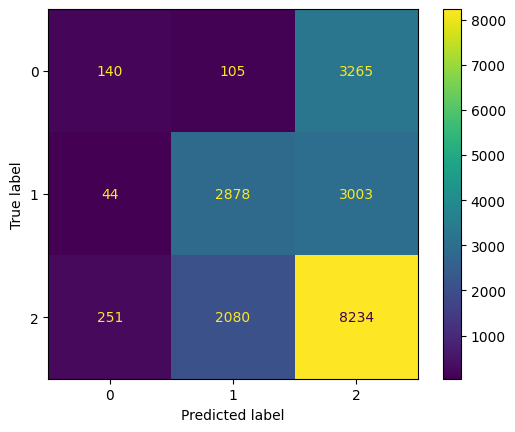

In [256]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_test, Y_pred))
disp.plot()
plt.show()

In [257]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.32      0.04      0.07      3510
           1       0.57      0.49      0.52      5925
           2       0.57      0.78      0.66     10565

    accuracy                           0.56     20000
   macro avg       0.49      0.43      0.42     20000
weighted avg       0.52      0.56      0.51     20000



In [258]:
# модель с отобранными признаками

Scaler_X2 = StandardScaler()
X2_train  = Scaler_X2.fit_transform(X2_train)
X2_test   = Scaler_X2.transform(X2_test)

model2 = LogisticRegression()
model2.fit(X2_train, Y_train)

Y_pred = model2.predict(X2_test)

print('Accuracy on the test set: %.2f' % accuracy_score(Y_test, Y_pred))
print('Confusion matrix:\n', confusion_matrix(Y_test, Y_pred))

Accuracy on the test set: 0.57
Confusion matrix:
 [[ 152   94 3264]
 [  62 2792 3071]
 [ 189 1993 8383]]


Accuracy on the test set: 0.53
Confusion matrix:
 [[    0     0  3527]
 [    0     0  5950]
 [    0     0 10523]]


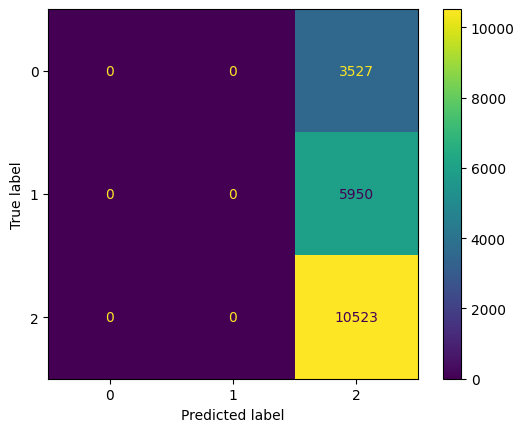

In [259]:
#кодируем признаки
labelEncoder_X = LabelEncoder()

df['Occupation'] = labelEncoder_X.fit_transform(df['Occupation'])
df['Credit_Mix'] = labelEncoder_X.fit_transform(df['Credit_Mix'])
df['Payment_of_Min_Amount'] = labelEncoder_X.fit_transform(df['Payment_of_Min_Amount'])
df['Payment_Behaviour'] = labelEncoder_X.fit_transform(df['Payment_Behaviour'])
df['Last_Loan_9'] = labelEncoder_X.fit_transform(df['Last_Loan_9'])
df['Last_Loan_8'] = labelEncoder_X.fit_transform(df['Last_Loan_8'])
df['Last_Loan_7'] = labelEncoder_X.fit_transform(df['Last_Loan_7'])
df['Last_Loan_6'] = labelEncoder_X.fit_transform(df['Last_Loan_6'])
df['Last_Loan_5'] = labelEncoder_X.fit_transform(df['Last_Loan_5'])
df['Last_Loan_4'] = labelEncoder_X.fit_transform(df['Last_Loan_4'])
df['Last_Loan_3'] = labelEncoder_X.fit_transform(df['Last_Loan_3'])
df['Last_Loan_2'] = labelEncoder_X.fit_transform(df['Last_Loan_2'])
df['Last_Loan_1'] = labelEncoder_X.fit_transform(df['Last_Loan_1'])
df['Customer_ID'] = labelEncoder_X.fit_transform(df['Customer_ID'])



#df['MaritalStatus']  = labelEncoder_X.fit_transform(df['MaritalStatus'])

   # 'Annual_Income',
   # 'Credit_Utilization_Ratio',
   # 'Age',
   # 'Outstanding_Debt',
   # 'Credit_History_Age'


label_encoder_y = LabelEncoder()

df['Credit_Score'] = label_encoder_y.fit_transform(df['Credit_Score'])

X = df.drop('Credit_Score', axis=1)
Y = df['Credit_Score']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2,random_state=5)

pca = PCA()
pca_values = pca.fit_transform(X)

pca= PCA(n_components = 1)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

model = LogisticRegression()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

print('Accuracy on the test set: %.2f' % accuracy_score(Y_test, Y_pred))
print('Confusion matrix:\n', confusion_matrix(Y_test, Y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_test, Y_pred))
disp.plot()
plt.show()

Как видим, это ситуацию не улучшило, а только ухудшило. Следовательно, однозначно предсказать рейтинг не получается. Лучше всего предсказывается стандартный, но с хорошим и плохим ничего не помогает(

КОНЕЦ. НИЧЕГО ХОРОШЕГО НЕ ПОЛУЧИЛОСЬ. ACCURACY 0.6636 — лучше уже не будет.